# project setup

In [1]:
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()

REPO_ROOT = CURRENT_DIR

while REPO_ROOT.name != "tube-bending-geometry":
    if REPO_ROOT == REPO_ROOT.parent:
        raise RuntimeError("Repository root was not found.")
    REPO_ROOT = REPO_ROOT.parent

QRF_ROOT = (
    REPO_ROOT
    / "src"
    / "pipeline"
    / "ml"
    / "qrf"
)

for path in (REPO_ROOT, QRF_ROOT):
    path_str = str(path)

    if path_str not in sys.path:
        sys.path.insert(0, path_str)

# imports

In [2]:
from mode.experiments.qrf_pipeline import (
    load_config,
    run_experiments,
)

from mode.experiments.plot import (
    plot_metric_by_tree_count,
    plot_prediction_interval,
)

# load config

In [3]:
PROJECT_ROOT = QRF_ROOT

CONFIG_PATH = (
    QRF_ROOT
    / "configs"
    / "tree_convergence_ranked.yaml"
)

config = load_config(
    config_path=CONFIG_PATH,
    project_root=REPO_ROOT,
)

#config

In [4]:
from copy import deepcopy

import pandas as pd


def select_ranked_split_indices(
    split_metadata: pd.DataFrame,
    rank_column: str,
    top_n: int,
    worst_n: int,
) -> dict[str, list[int]]:
    """
    Select the best and worst split indices according to one axis-specific
    QRF ranking column.

    Smaller rank values represent better splits.
    """

    required_columns = {
        "split_index",
        rank_column,
    }

    missing_columns = (
        required_columns
        - set(split_metadata.columns)
    )

    if missing_columns:
        raise KeyError(
            "Missing required split-metadata columns: "
            f"{sorted(missing_columns)}"
        )

    ranked_df = (
        split_metadata[
            [
                "split_index",
                rank_column,
            ]
        ]
        .dropna(
            subset=[
                "split_index",
                rank_column,
            ]
        )
        .drop_duplicates(
            subset=["split_index"]
        )
        .sort_values(
            by=[
                rank_column,
                "split_index",
            ],
            ascending=[
                True,
                True,
            ],
        )
        .reset_index(drop=True)
    )

    minimum_required_splits = (
        top_n
        + worst_n
    )

    if len(ranked_df) < minimum_required_splits:
        raise ValueError(
            f"Cannot select {top_n} top and {worst_n} worst splits "
            f"from only {len(ranked_df)} ranked splits."
        )

    top_split_indices = (
        ranked_df
        .head(top_n)["split_index"]
        .astype(int)
        .tolist()
    )

    worst_split_indices = (
        ranked_df
        .tail(worst_n)["split_index"]
        .astype(int)
        .tolist()
    )

    selected_split_indices = list(
        dict.fromkeys(
            top_split_indices
            + worst_split_indices
        )
    )

    return {
        "top": top_split_indices,
        "worst": worst_split_indices,
        "all": selected_split_indices,
    }


SPLIT_METADATA_PATH = (
    REPO_ROOT
    / config["paths"]["split_metadata"]
)

split_metadata_df = pd.read_parquet(
    SPLIT_METADATA_PATH
)

split_selection_config = (
    config["search"]["split_selection"]
)

top_n = int(
    split_selection_config["top_n"]
)

worst_n = int(
    split_selection_config["worst_n"]
)

rank_columns = (
    split_selection_config["rank_columns"]
)

selected_splits_by_axis = {}

for axis in config["search"]["axes"]:
    selected_splits_by_axis[axis] = (
        select_ranked_split_indices(
            split_metadata=split_metadata_df,
            rank_column=rank_columns[axis],
            top_n=top_n,
            worst_n=worst_n,
        )
    )

selected_splits_by_axis

{'main': {'top': [70, 76, 43],
  'worst': [33, 9, 25],
  'all': [70, 76, 43, 33, 9, 25]},
 'secondary': {'top': [66, 50, 16],
  'worst': [101, 21, 73],
  'all': [66, 50, 16, 101, 21, 73]}}

# run

In [5]:
axis_metrics = []
axis_predictions = []
run_directories = {}

for axis in config["search"]["axes"]:
    axis_config = deepcopy(config)

    axis_config["experiment_name"] = (
        f'{config["experiment_name"]}_{axis}'
    )

    # Run only one target axis in this execution.
    axis_config["search"]["axes"] = [
        axis
    ]

    # Axis-specific top and worst splits.
    axis_config["search"]["split_indices"] = (
        selected_splits_by_axis[axis]["all"]
    )

    print(
        f"\nRunning axis: {axis}"
    )

    print(
        "Top splits:",
        selected_splits_by_axis[axis]["top"],
    )

    print(
        "Worst splits:",
        selected_splits_by_axis[axis]["worst"],
    )

    (
        current_metrics_df,
        current_predictions_df,
        current_run_dir,
    ) = run_experiments(
        axis_config
    )

    current_metrics_df = (
        current_metrics_df.copy()
    )

    current_metrics_df[
        "selection_group"
    ] = current_metrics_df[
        "split_index"
    ].map(
        {
            **{
                split_index: "top"
                for split_index
                in selected_splits_by_axis[axis]["top"]
            },
            **{
                split_index: "worst"
                for split_index
                in selected_splits_by_axis[axis]["worst"]
            },
        }
    )

    if current_predictions_df is not None:
        current_predictions_df = (
            current_predictions_df.copy()
        )

        current_predictions_df[
            "selection_group"
        ] = current_predictions_df[
            "split_index"
        ].map(
            {
                **{
                    split_index: "top"
                    for split_index
                    in selected_splits_by_axis[axis]["top"]
                },
                **{
                    split_index: "worst"
                    for split_index
                    in selected_splits_by_axis[axis]["worst"]
                },
            }
        )

        axis_predictions.append(
            current_predictions_df
        )

    axis_metrics.append(
        current_metrics_df
    )

    run_directories[axis] = (
        current_run_dir
    )


metrics_df = pd.concat(
    axis_metrics,
    ignore_index=True,
)

if axis_predictions:
    predictions_df = pd.concat(
        axis_predictions,
        ignore_index=True,
    )
else:
    predictions_df = pd.DataFrame()

run_dir = run_directories

#print("\nRun directories:")

#for axis, axis_run_dir in run_directories.items():
#    print(
#        f"{axis}: {axis_run_dir}"
#    )

#display(
#    metrics_df.sort_values(
#        by=[
#            "axis",
#            "selection_group",
#            "split_index",
#            "n_estimators",
#        ],
#    )
#)


Running axis: main
Top splits: [70, 76, 43]
Worst splits: [33, 9, 25]
Finished split-070__trees-0010__axis-main: coverage=23.45% | rmse=0.4232
Finished split-070__trees-0020__axis-main: coverage=28.11% | rmse=0.4291
Finished split-070__trees-0030__axis-main: coverage=29.10% | rmse=0.4303
Finished split-070__trees-0040__axis-main: coverage=29.67% | rmse=0.4306
Finished split-070__trees-0050__axis-main: coverage=29.75% | rmse=0.4311
Finished split-070__trees-0060__axis-main: coverage=29.75% | rmse=0.4309
Finished split-070__trees-0070__axis-main: coverage=29.78% | rmse=0.4308
Finished split-070__trees-0080__axis-main: coverage=29.70% | rmse=0.4309
Finished split-070__trees-0090__axis-main: coverage=29.78% | rmse=0.4309
Finished split-070__trees-0100__axis-main: coverage=29.70% | rmse=0.4309
Finished split-076__trees-0010__axis-main: coverage=28.35% | rmse=0.2601
Finished split-076__trees-0020__axis-main: coverage=29.09% | rmse=0.2618
Finished split-076__trees-0030__axis-main: coverage=2

# Effect of split definition on QRF performance

Each categorical train/test split is evaluated using the four components
of the QRF ranking score:

- absolute empirical-coverage error from the nominal 90% interval,
- root mean squared error,
- mean absolute error,
- mean prediction-interval width.

Main-axis and secondary-axis results are ranked independently. Lower
values indicate better performance for all displayed metrics.

# Main and secondary QRF convergence

The two target axes are evaluated separately. The table reports the
QRF-ranking components used to explain why a split with higher coverage
may still receive a worse overall rank.

In [6]:
selected_split_rows = []

for axis, groups in selected_splits_by_axis.items():
    rank_column = (
        config["search"]
        ["split_selection"]
        ["rank_columns"]
        [axis]
    )

    for selection_group in (
        "top",
        "worst",
    ):
        split_indices = groups[
            selection_group
        ]

        current_rows = (
            split_metadata_df.loc[
                split_metadata_df[
                    "split_index"
                ].isin(split_indices)
            ]
            .copy()
        )

        current_rows["axis"] = axis
        current_rows[
            "selection_group"
        ] = selection_group

        current_rows[
            "selected_axis_rank"
        ] = current_rows[
            rank_column
        ]

        selected_split_rows.append(
            current_rows
        )


selected_split_summary_df = pd.concat(
    selected_split_rows,
    ignore_index=True,
)

selected_split_summary_df = (
    selected_split_summary_df
    .sort_values(
        by=[
            "axis",
            "selected_axis_rank",
        ]
    )
    .reset_index(drop=True)
)

display_columns = [
    "axis",
    "selection_group",
    "split_index",
    "selected_axis_rank",
]

optional_columns = [
    "split_name",
    "split_features",
    "split_conditions",
]

display_columns += [
    column
    for column in optional_columns
    if column
    in selected_split_summary_df.columns
]

display(
    selected_split_summary_df[
        display_columns
    ]
)

,axis,selection_group,split_index,selected_axis_rank,split_name,split_features,split_conditions
0,main,top,70,1,"Mandrel retraction timing in [2, 10]__AND__Col...","[Mandrel retraction timing, Collet boost]","[Mandrel retraction timing=2, Mandrel retracti..."
1,main,top,76,2,"Mandrel retraction timing in [2, 5]__AND__Coll...","[Mandrel retraction timing, Collet boost]","[Mandrel retraction timing=2, Mandrel retracti..."
2,main,top,43,3,Mandrel retraction timing=5__AND__Collet boost...,"[Mandrel retraction timing, Collet boost]","[Mandrel retraction timing=5, Collet boost=0.95]"
3,main,worst,33,112,Mandrel retraction timing=10__AND__Collet boos...,"[Mandrel retraction timing, Collet boost]","[Mandrel retraction timing=10, Collet boost=0.9]"
4,main,worst,9,113,Mandrel retraction timing=5,[Mandrel retraction timing],[Mandrel retraction timing=5]
5,main,worst,25,114,"Mandrel retraction timing in [5, 10]",[Mandrel retraction timing],"[Mandrel retraction timing=5, Mandrel retracti..."
6,secondary,top,66,1,"Mandrel retraction timing in [0, 5]__AND__Coll...","[Mandrel retraction timing, Collet boost]","[Mandrel retraction timing=0, Mandrel retracti..."
7,secondary,top,50,2,"Collet boost in [0.87, 0.9, 0.92]",[Collet boost],"[Collet boost=0.87, Collet boost=0.9, Collet b..."
8,secondary,top,16,3,"Collet boost in [0.87, 0.9]",[Collet boost],"[Collet boost=0.87, Collet boost=0.9]"
9,secondary,worst,101,112,Mandrel retraction timing=10__AND__Collet boos...,"[Mandrel retraction timing, Collet boost]","[Mandrel retraction timing=10, Collet boost=0...."


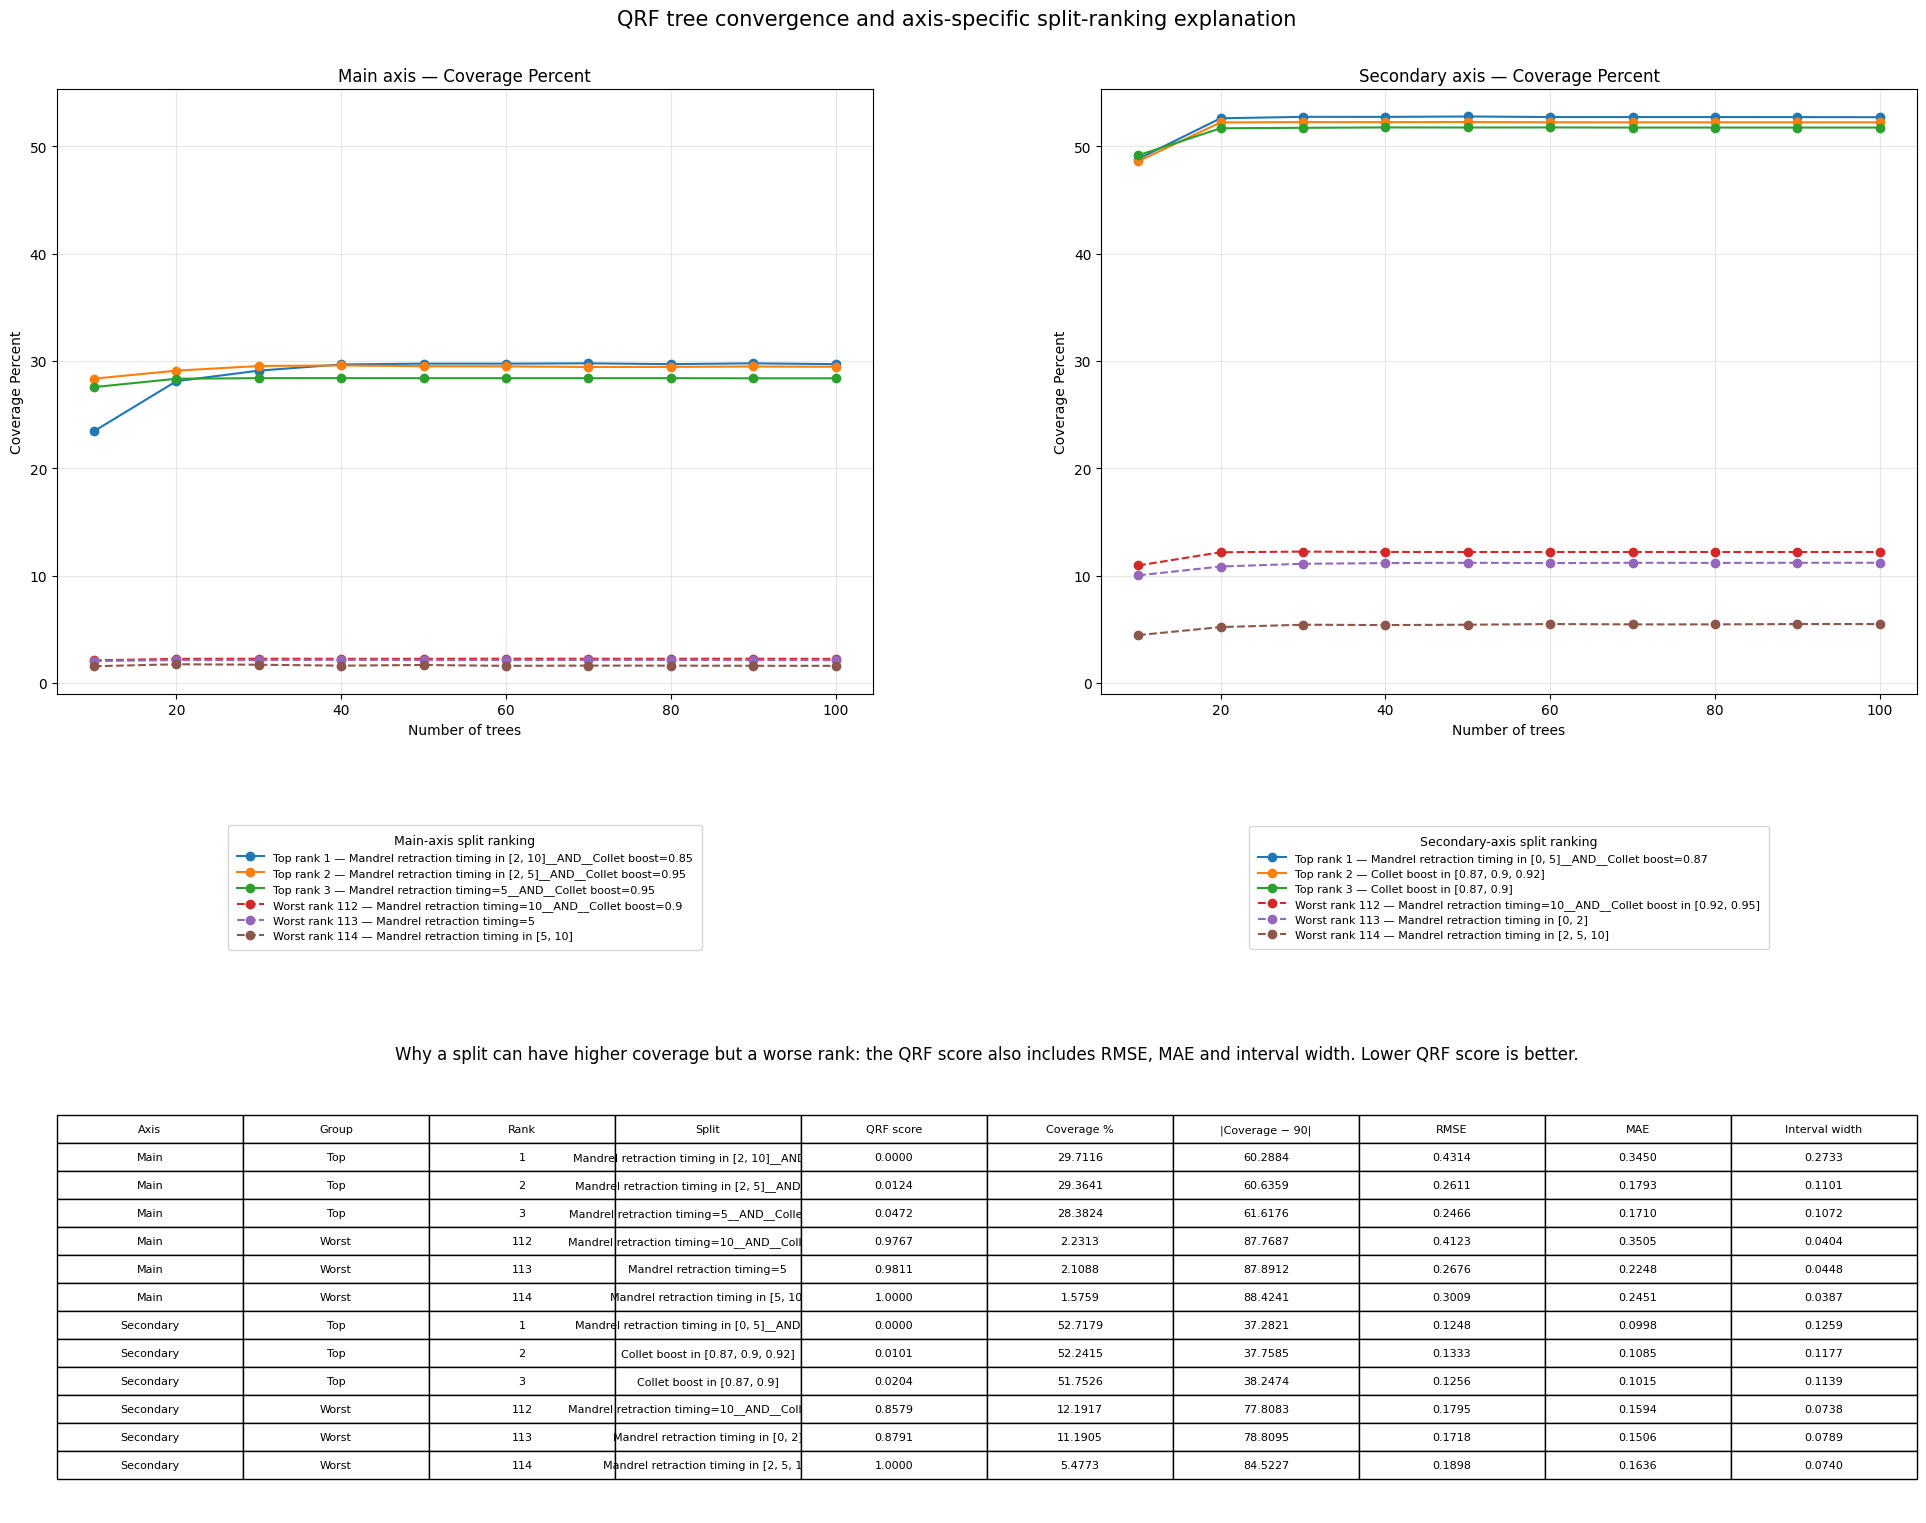

In [7]:
from mode.experiments.plot import (
    plot_main_secondary_convergence_with_ranking,
)

SPLIT_METADATA_PATH = (
    REPO_ROOT
    / config["paths"]["split_metadata"]
)

ranking_explanation_df = (
    plot_main_secondary_convergence_with_ranking(
        metrics_df=metrics_df,
        split_metadata=SPLIT_METADATA_PATH,
        metric="coverage_percent",
        top_n=config["search"]["split_selection"]["top_n"],
        worst_n=config["search"]["split_selection"]["worst_n"],
    )
)

### RMSE plot

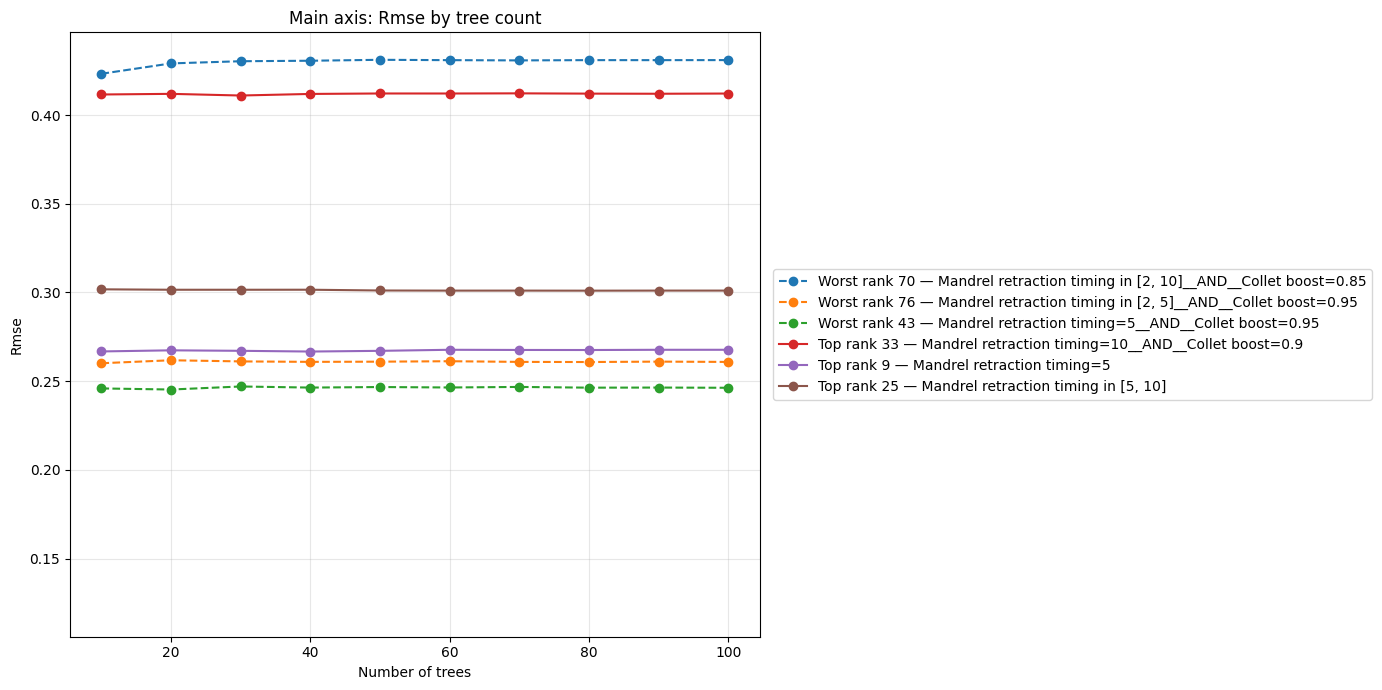

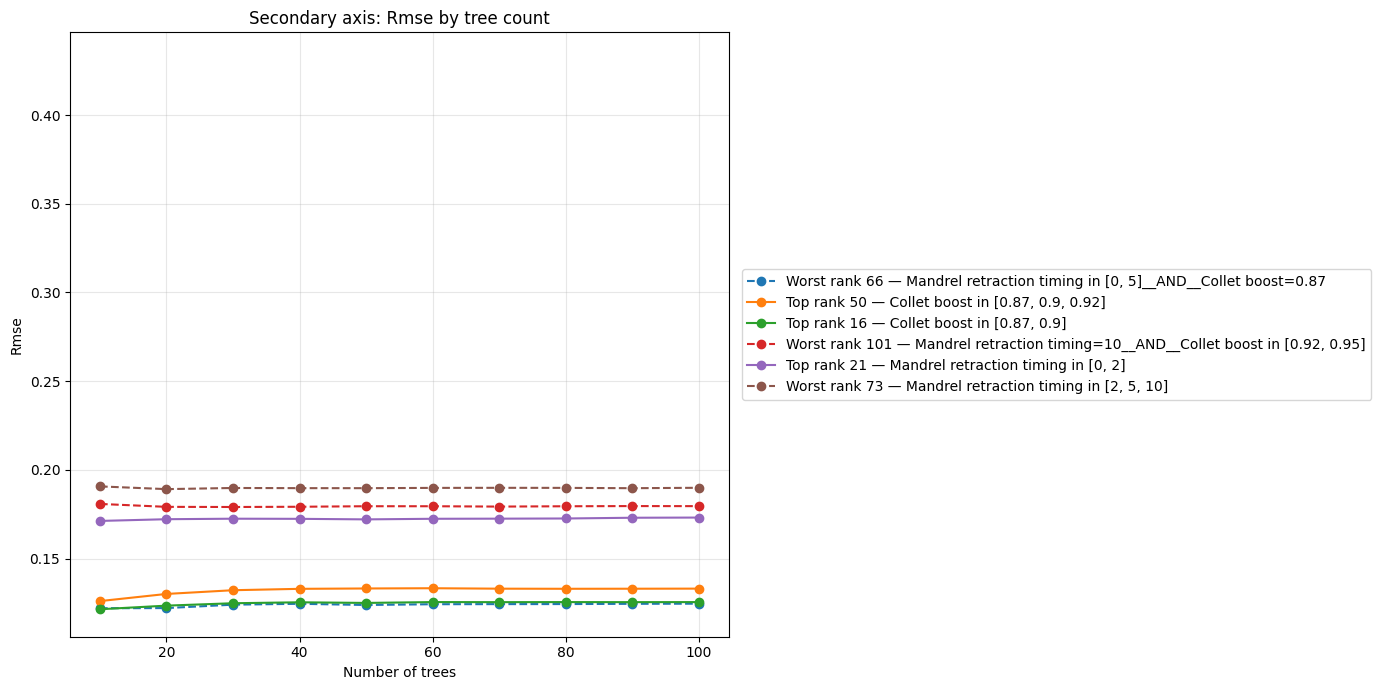

In [8]:
metric = "rmse"

metric_values = pd.to_numeric(
    metrics_df[metric],
    errors="coerce",
).dropna()

metric_min = float(metric_values.min())
metric_max = float(metric_values.max())

metric_range = metric_max - metric_min

padding = (
    metric_range * 0.05
    if metric_range > 0
    else max(abs(metric_min), 1.0) * 0.05
)

shared_ylim = (
    metric_min - padding,
    metric_max + padding,
)

for axis in config["search"]["axes"]:
    plot_metric_by_tree_count(
        metrics_df=metrics_df,
        metric=metric,
        axis=axis,
        top_n=config["search"]["split_selection"]["top_n"],
        worst_n=config["search"]["split_selection"]["worst_n"],
        ylim=shared_ylim,
    )

# Bending-Setup Feature Ranking and Group-Spread Visualization

This notebook visualizes the ranked bending-setup features.

For each ranked feature:

- The feature values are shown as the main groups on the x-axis.
- Each bending setup group is represented by a separate bar.
- The y-axis represents the selected group-spread metric, such as PINAW or mean pairwise distance.
- Features are plotted according to their ranking order.

In [9]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd().resolve()

REPO_ROOT = CURRENT_DIR

while REPO_ROOT.name != "tube-bending-geometry":
    if REPO_ROOT == REPO_ROOT.parent:
        raise RuntimeError("Repository root was not found.")
    REPO_ROOT = REPO_ROOT.parent

QRF_ROOT = (
    REPO_ROOT
    / "src"
    / "pipeline"
    / "ml"
    / "qrf"
)

for path in [REPO_ROOT, QRF_ROOT]:
    path_str = str(path)

    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from mode.experiments.bending_ranked_feature_plot import (
    PAIRWISE_DISTANCE_COLUMN,
    STD_DISTANCE_COLUMN,
    build_feature_plot_dataframe,
    compute_group_mean_pairwise_distance,
    compute_group_std_distance,
    convert_group_id,
    get_available_ranked_features,
    plot_adjusted_effect_by_feature_value,
    plot_metric_distribution_by_feature_value,
    plot_metric_mean_median_trend,
    plot_ranked_feature_group_spread,
    resolve_column_name,
    select_ranked_features,
)

In [10]:
TOP_N_FEATURES = None

RANKING_PATH = (
    QRF_ROOT
    / "data"
    / "bending_setup_group_spread_feature_ranking.parquet"
)

BENDING_SETUP_PATH = (
    REPO_ROOT
    / "data"
    / "rf_augmented"
    / "ui_data"
    / "unique_bending_setups.csv"
)

EXPERIMENT_DATA_PATH = (
    REPO_ROOT
    / "data"
    / "rf_augmented"
    / "ui_data"
    / "final_geometry_within_group_interpolation_raw.csv"
)

In [11]:
ranking_df = pd.read_parquet(RANKING_PATH)
bending_setup_df = pd.read_csv(BENDING_SETUP_PATH)
experiment_df = pd.read_csv(EXPERIMENT_DATA_PATH)

bending_group_column = resolve_column_name(
    bending_setup_df,
    "Group_ID",
)

experiment_group_column = resolve_column_name(
    experiment_df,
    "Group_ID",
)

bending_setup_df[bending_group_column] = convert_group_id(
    bending_setup_df[bending_group_column]
)

experiment_df[experiment_group_column] = convert_group_id(
    experiment_df[experiment_group_column]
)

## Top 3 and worst 3 split train-value maps

This section compares the **three best** and **three worst** QRF-ranked splits.

The function creates six figures:

1. Top rank 1
2. Top rank 2
3. Top rank 3
4. Worst rank 1
5. Worst rank 2
6. Worst rank 3

Each figure contains two panels:

- **Left:** main-axis split
- **Right:** secondary-axis split

For every bending-setup feature, all observed values are normalised independently
to the range `[-1, 1]`.

- A **filled blue circle** means that value occurs in at least one training group.
- An **open black circle** means that value does not occur in any training group.

Train membership is determined from `train_group_ids` in
`various_splits.parquet` and `Group_ID` in `unique_bending_setups.csv`.

The metrics box reports the available axis-specific test metrics.

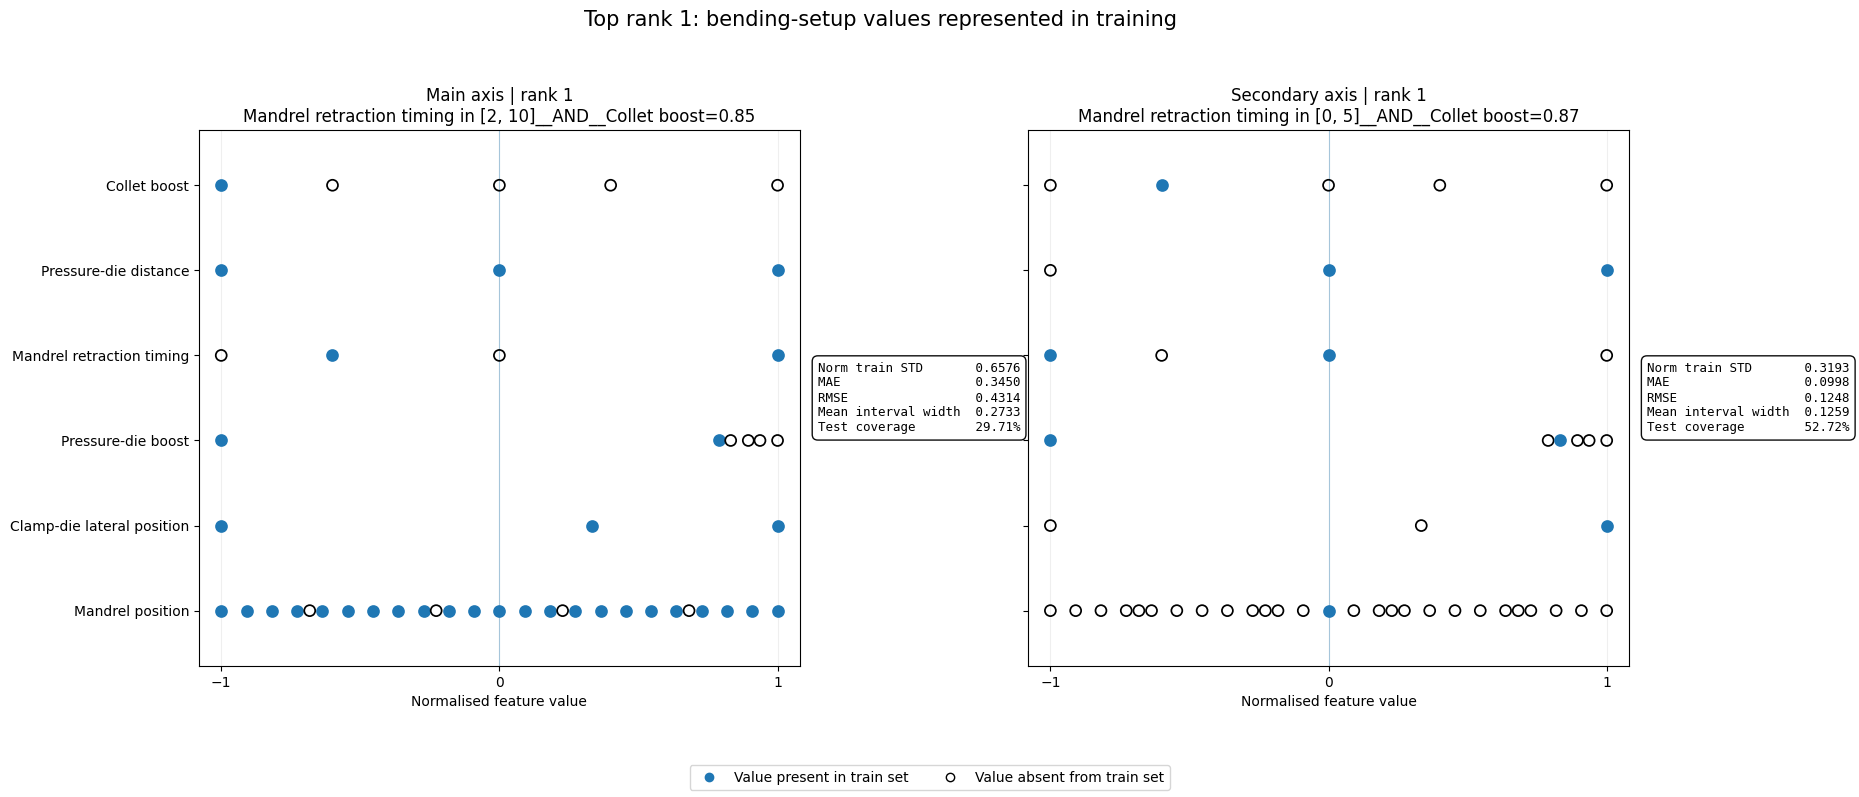

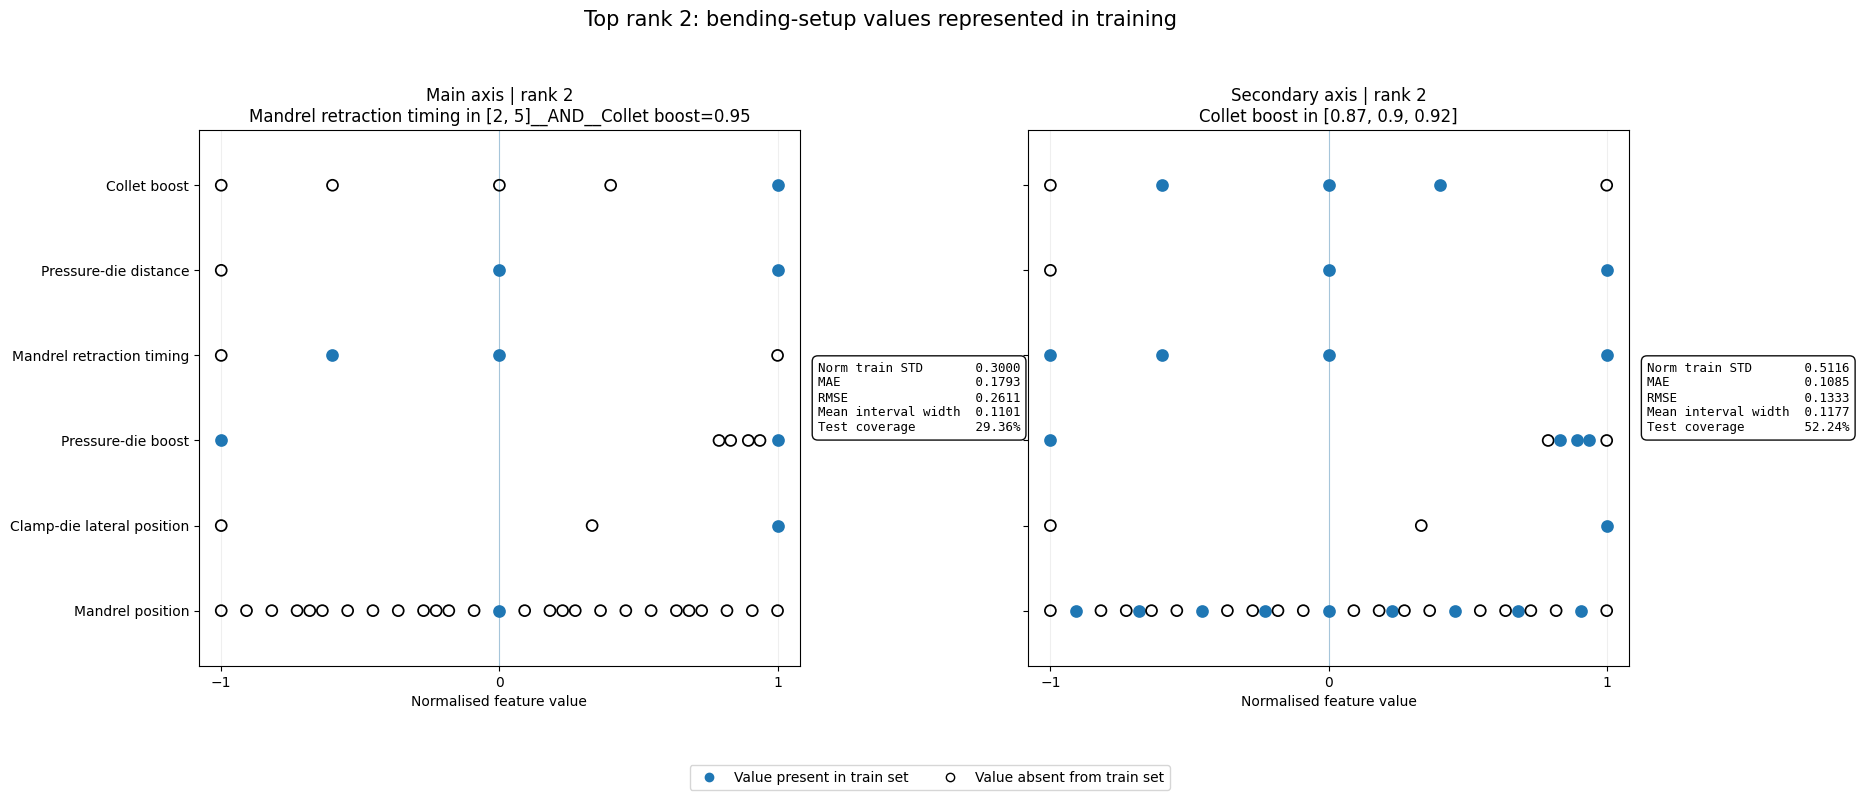

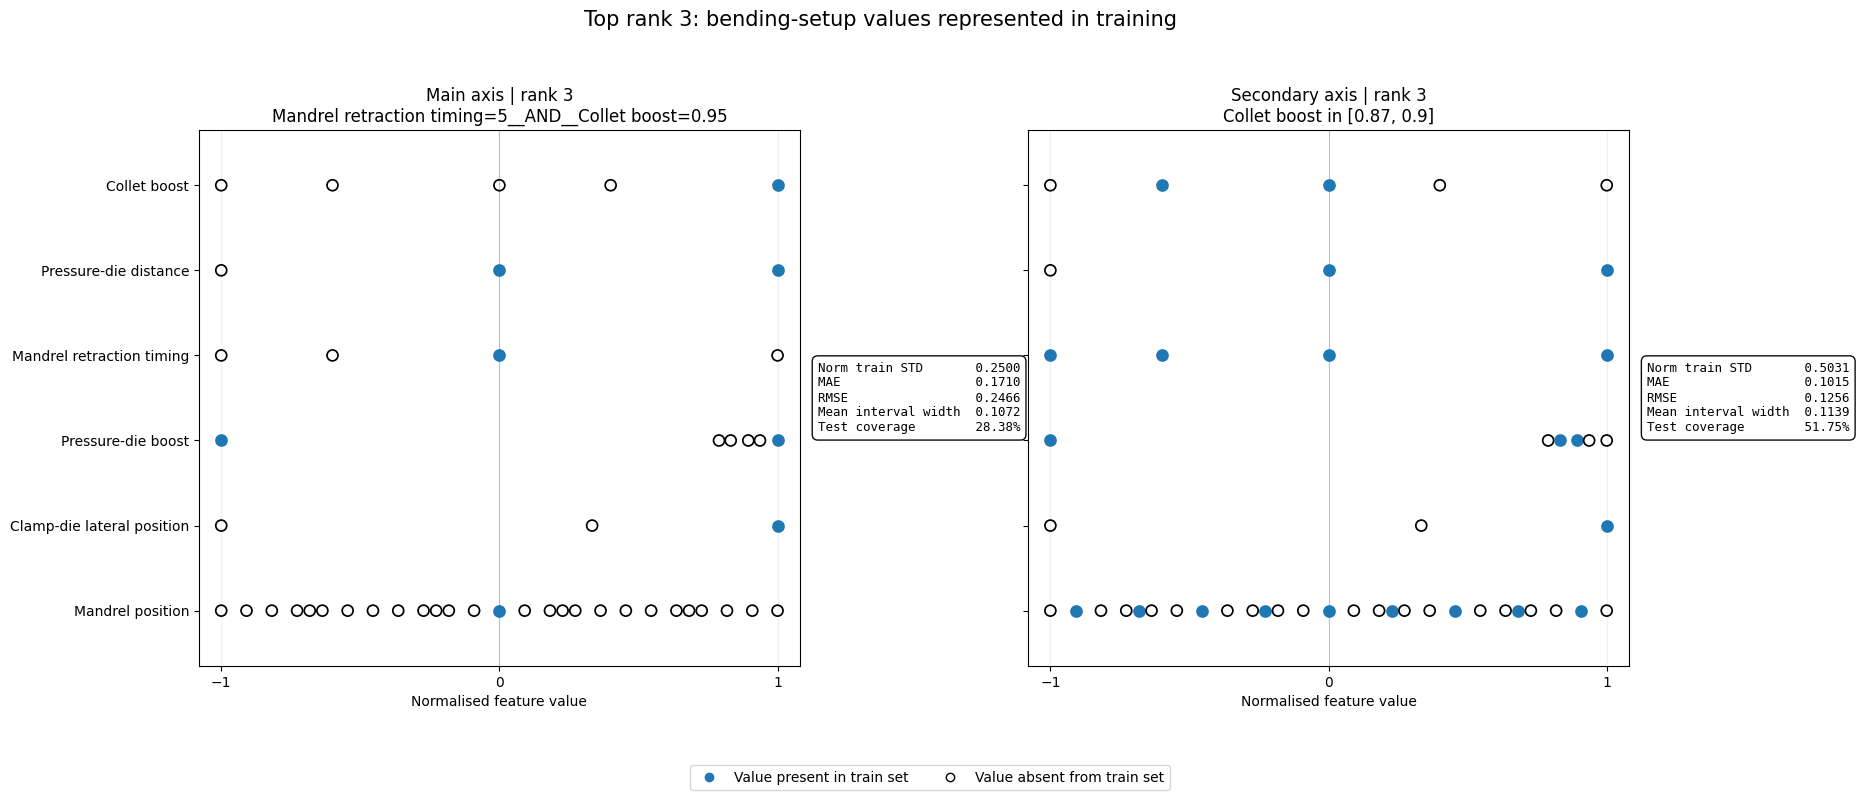

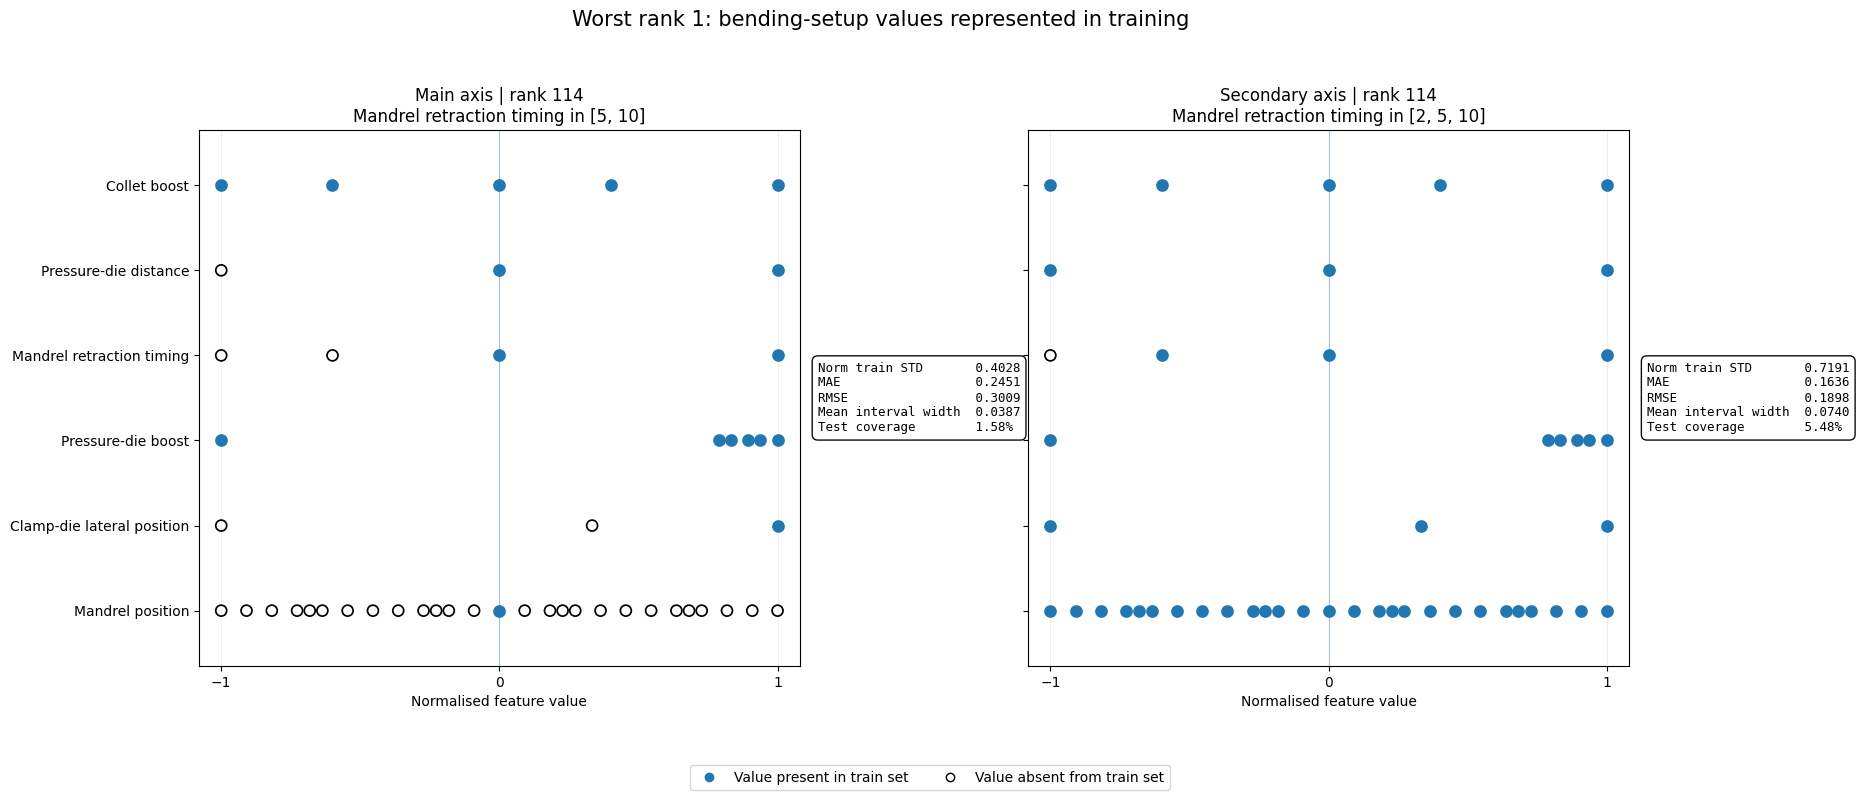

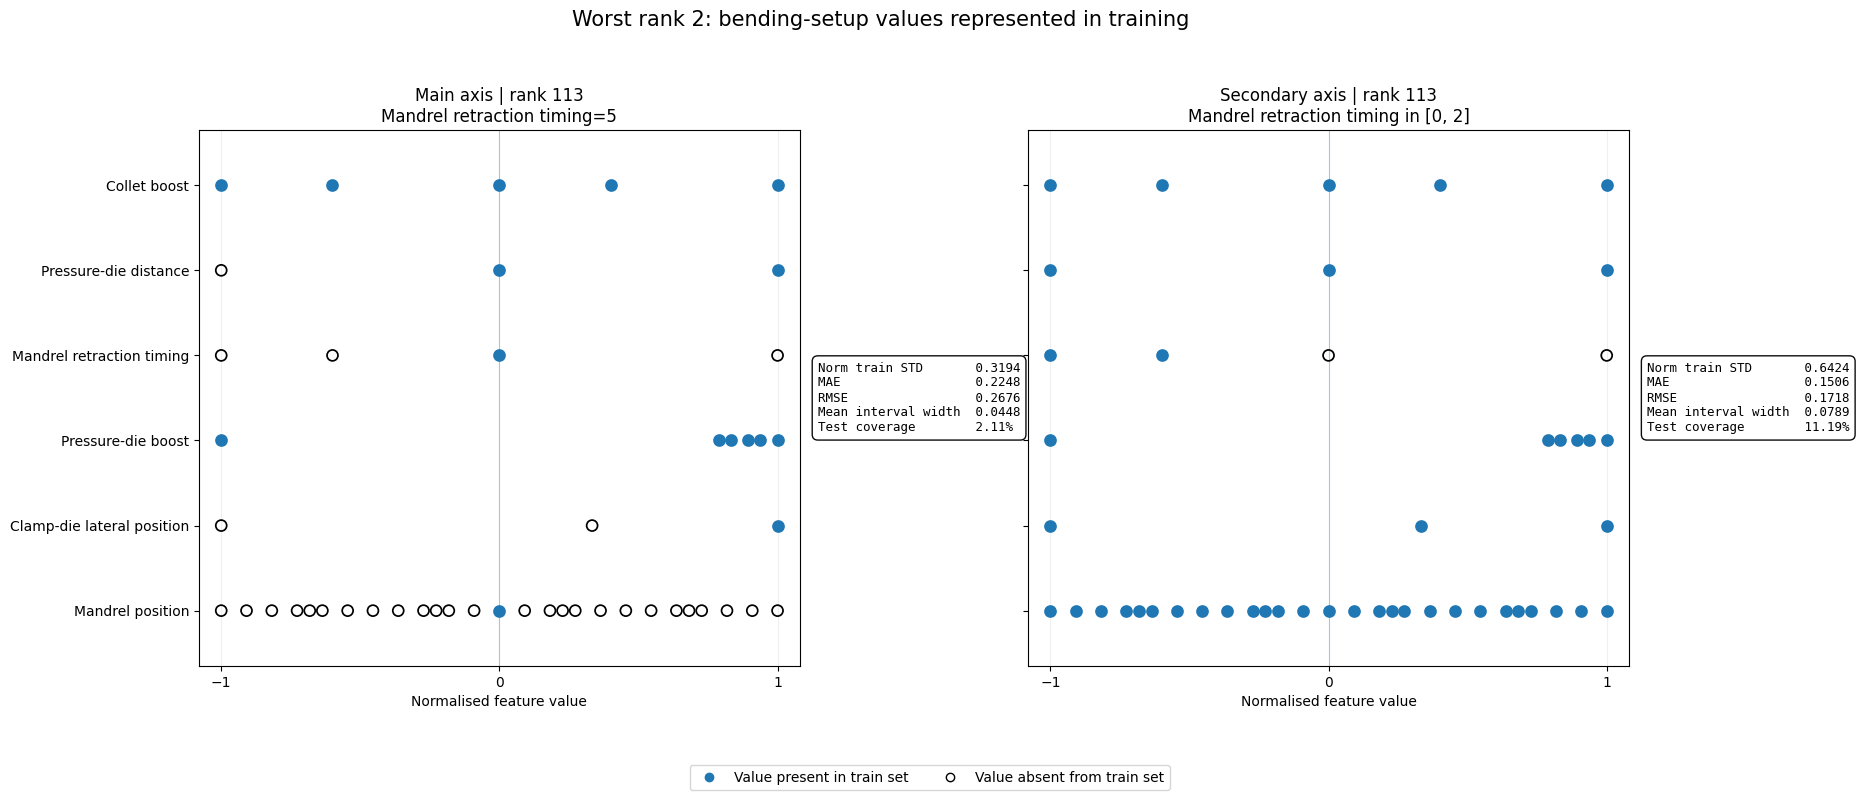

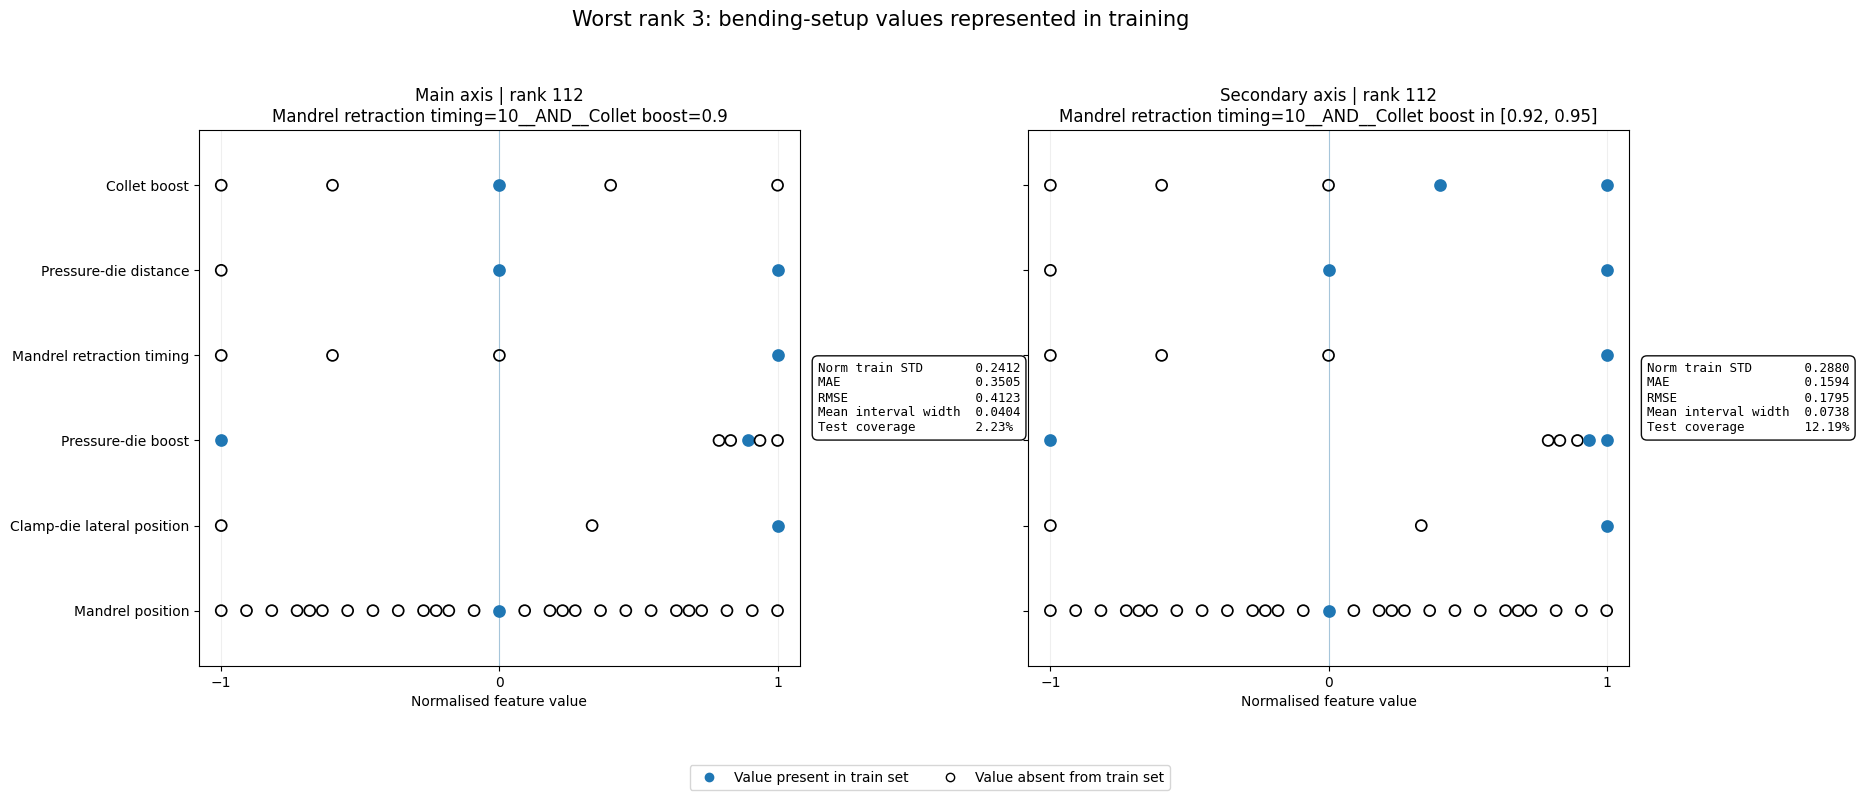

In [12]:
from mode.experiments.plot import (
    plot_top_worst_split_value_maps,
)

SPLIT_VALUE_FEATURES = [
    "Collet boost",
    "Pressure-die distance",
    "Mandrel retraction timing",
    "Pressure-die boost",
    "Clamp-die lateral position",
    "Mandrel position",
]

split_value_figures, split_value_summary_df = (
    plot_top_worst_split_value_maps(
        split_metadata=split_metadata_df,
        bending_setup_df=bending_setup_df,
        feature_names=SPLIT_VALUE_FEATURES,
        bending_group_column=bending_group_column,
        train_group_ids_column="train_group_ids",
        top_n=3,
        worst_n=3,
        figsize=(22, 8),
        marker_size=62,
        show=True,
    )
)

#display(split_value_summary_df)

# Coverage Trend

In [ ]:
from mode.experiments.plot import (
    plot_split_coverage_by_split_name,
)

coverage_figure, coverage_summary_df = (
    plot_split_coverage_by_split_name(
        split_metadata=split_metadata_df,
        sort_by="coverage",
        ascending=False,
        figsize=(18, 6),
        marker_size=44,
        show_split_names=False,
        show=True,
    )
)

# display(coverage_summary_df)

In [13]:
ranked_features_main_df, _, feature_column, rank_column, _ = (
    select_ranked_features(
        ranking_data=ranking_df,
        geometry_type="main",
        top_n_features=TOP_N_FEATURES,
    )
)

available_ranked_features, missing_ranked_features = get_available_ranked_features(
    ranked_features=ranked_features_main_df,
    bending_data=bending_setup_df,
    feature_column=feature_column,
)

if missing_ranked_features:
    print("Features missing from bending setup data:")
    for feature_name in missing_ranked_features:
        print(f"  - {feature_name}")

display(ranked_features_main_df)

,feature,rank
0,Collet boost,1
1,Pressure-die distance,2
2,Mandrel retraction timing,3
3,Pressure-die boost,4
4,Clamp-die lateral position,5
5,Mandrel position,6


In [14]:
def build_axis_plot_data(
    feature_name: str,
    geometry_type: str,
    distance_columns: list[str],
):
    ranked_features_axis_df, _, feature_column, rank_column, _ = (
        select_ranked_features(
            ranking_data=ranking_df,
            geometry_type=geometry_type,
            top_n_features=None,
        )
    )

    feature_rank = ranked_features_axis_df.loc[
        ranked_features_axis_df[feature_column].eq(feature_name),
        rank_column,
    ].iloc[0]

    group_distance_df = compute_group_mean_pairwise_distance(
        dataframe=experiment_df,
        group_column=experiment_group_column,
        distance_columns=distance_columns,
        standardize=True,
    )

    group_distance_df = group_distance_df.rename(
        columns={
            experiment_group_column: bending_group_column,
        }
    )

    feature_plot_df = build_feature_plot_dataframe(
        feature_name=feature_name,
        bending_data=bending_setup_df,
        group_distance_data=group_distance_df,
        bending_group_name=bending_group_column,
        metric_name=PAIRWISE_DISTANCE_COLUMN,
    )

    return feature_plot_df, feature_rank

Mean Pairwise based

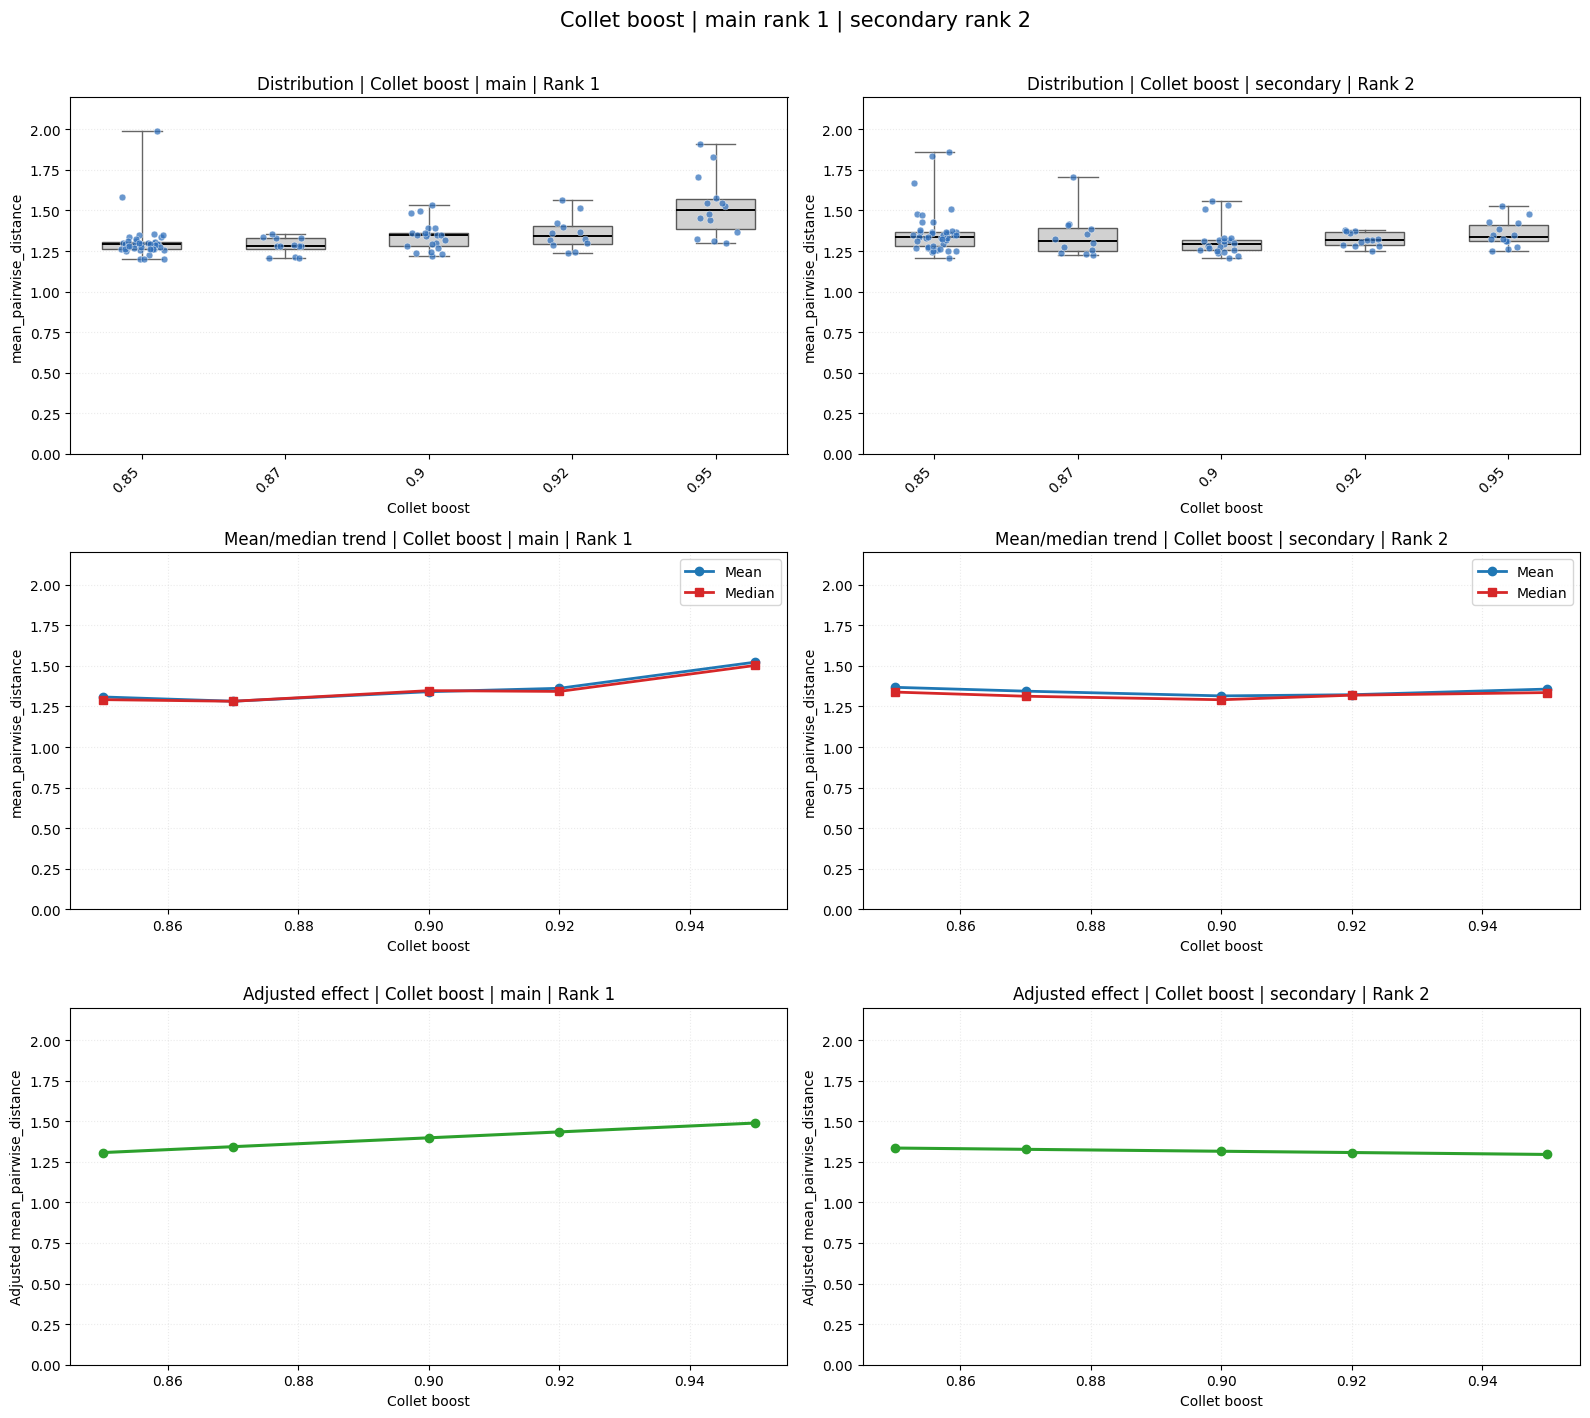

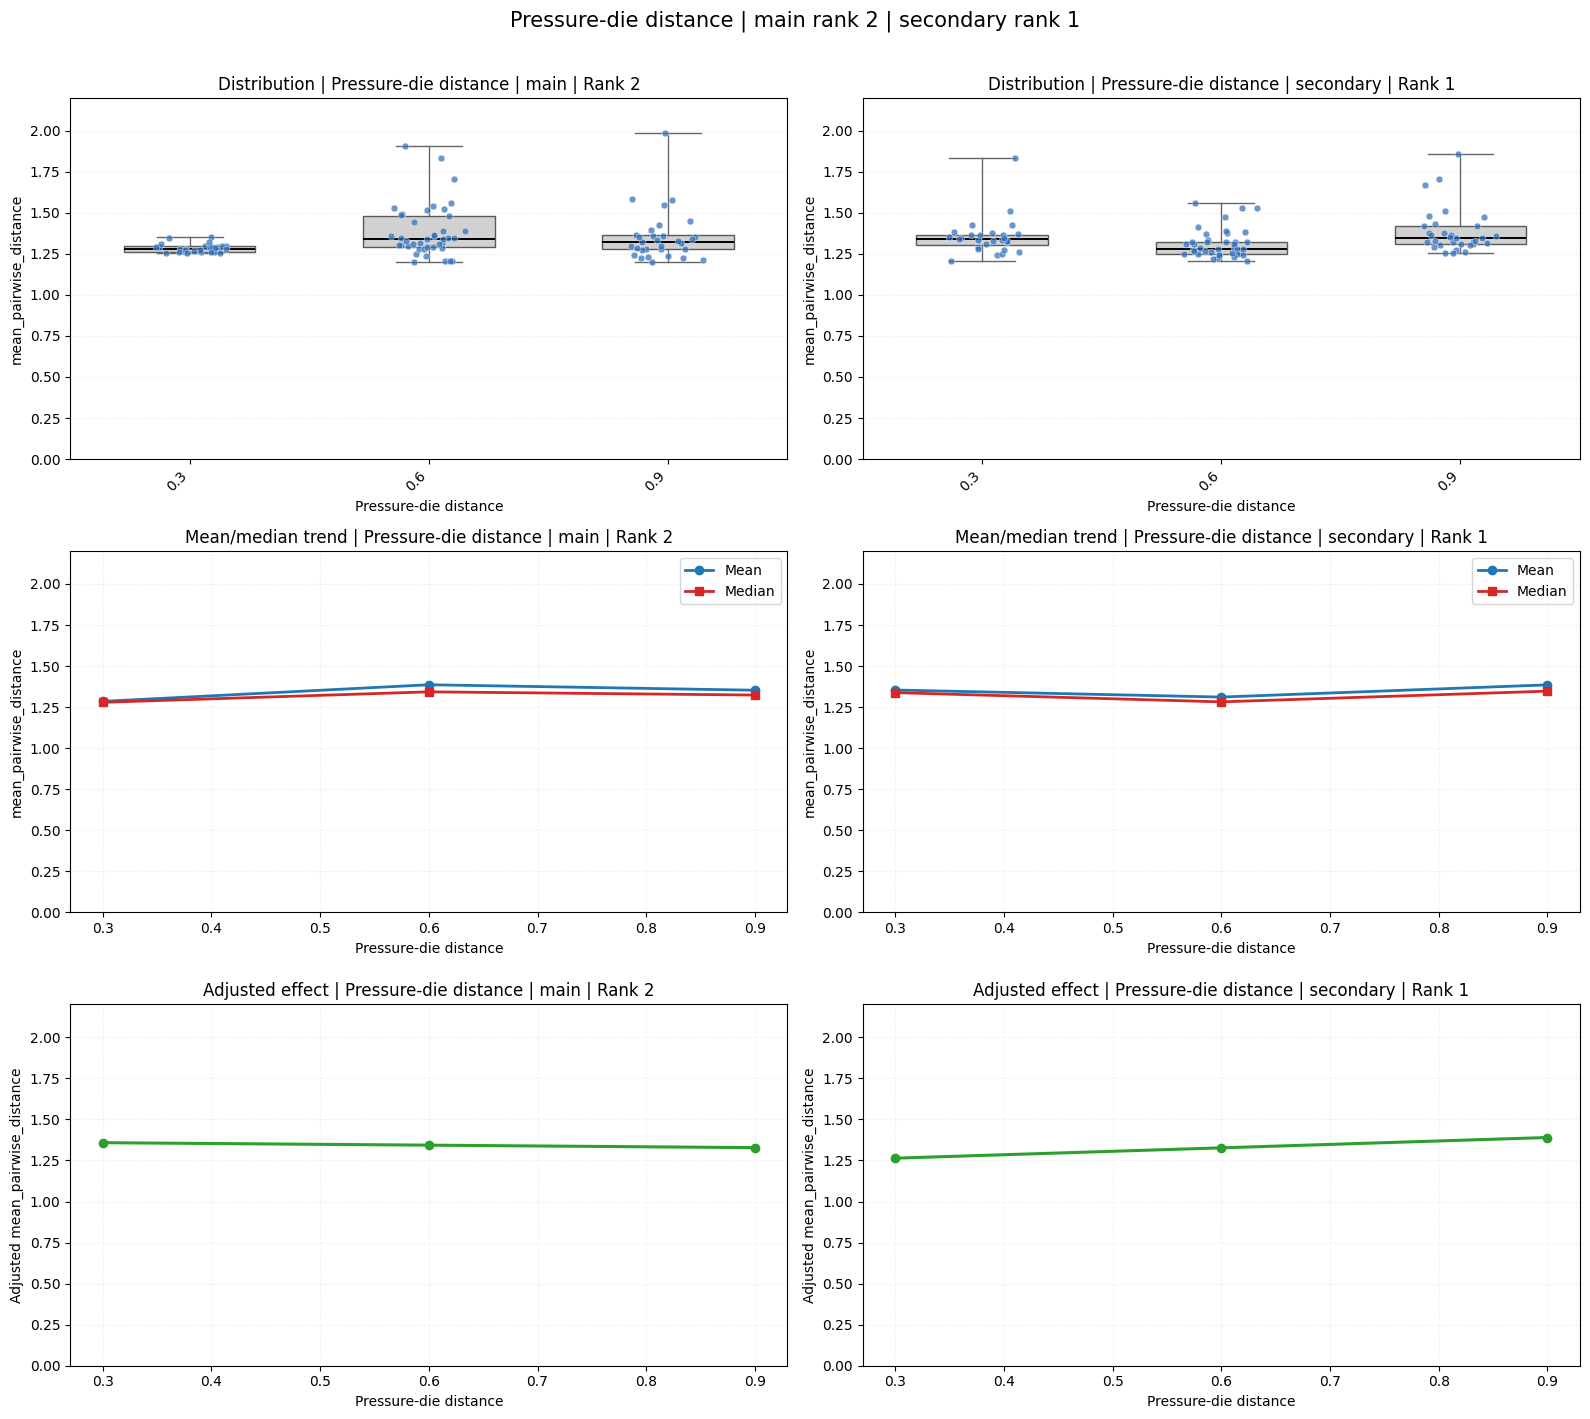

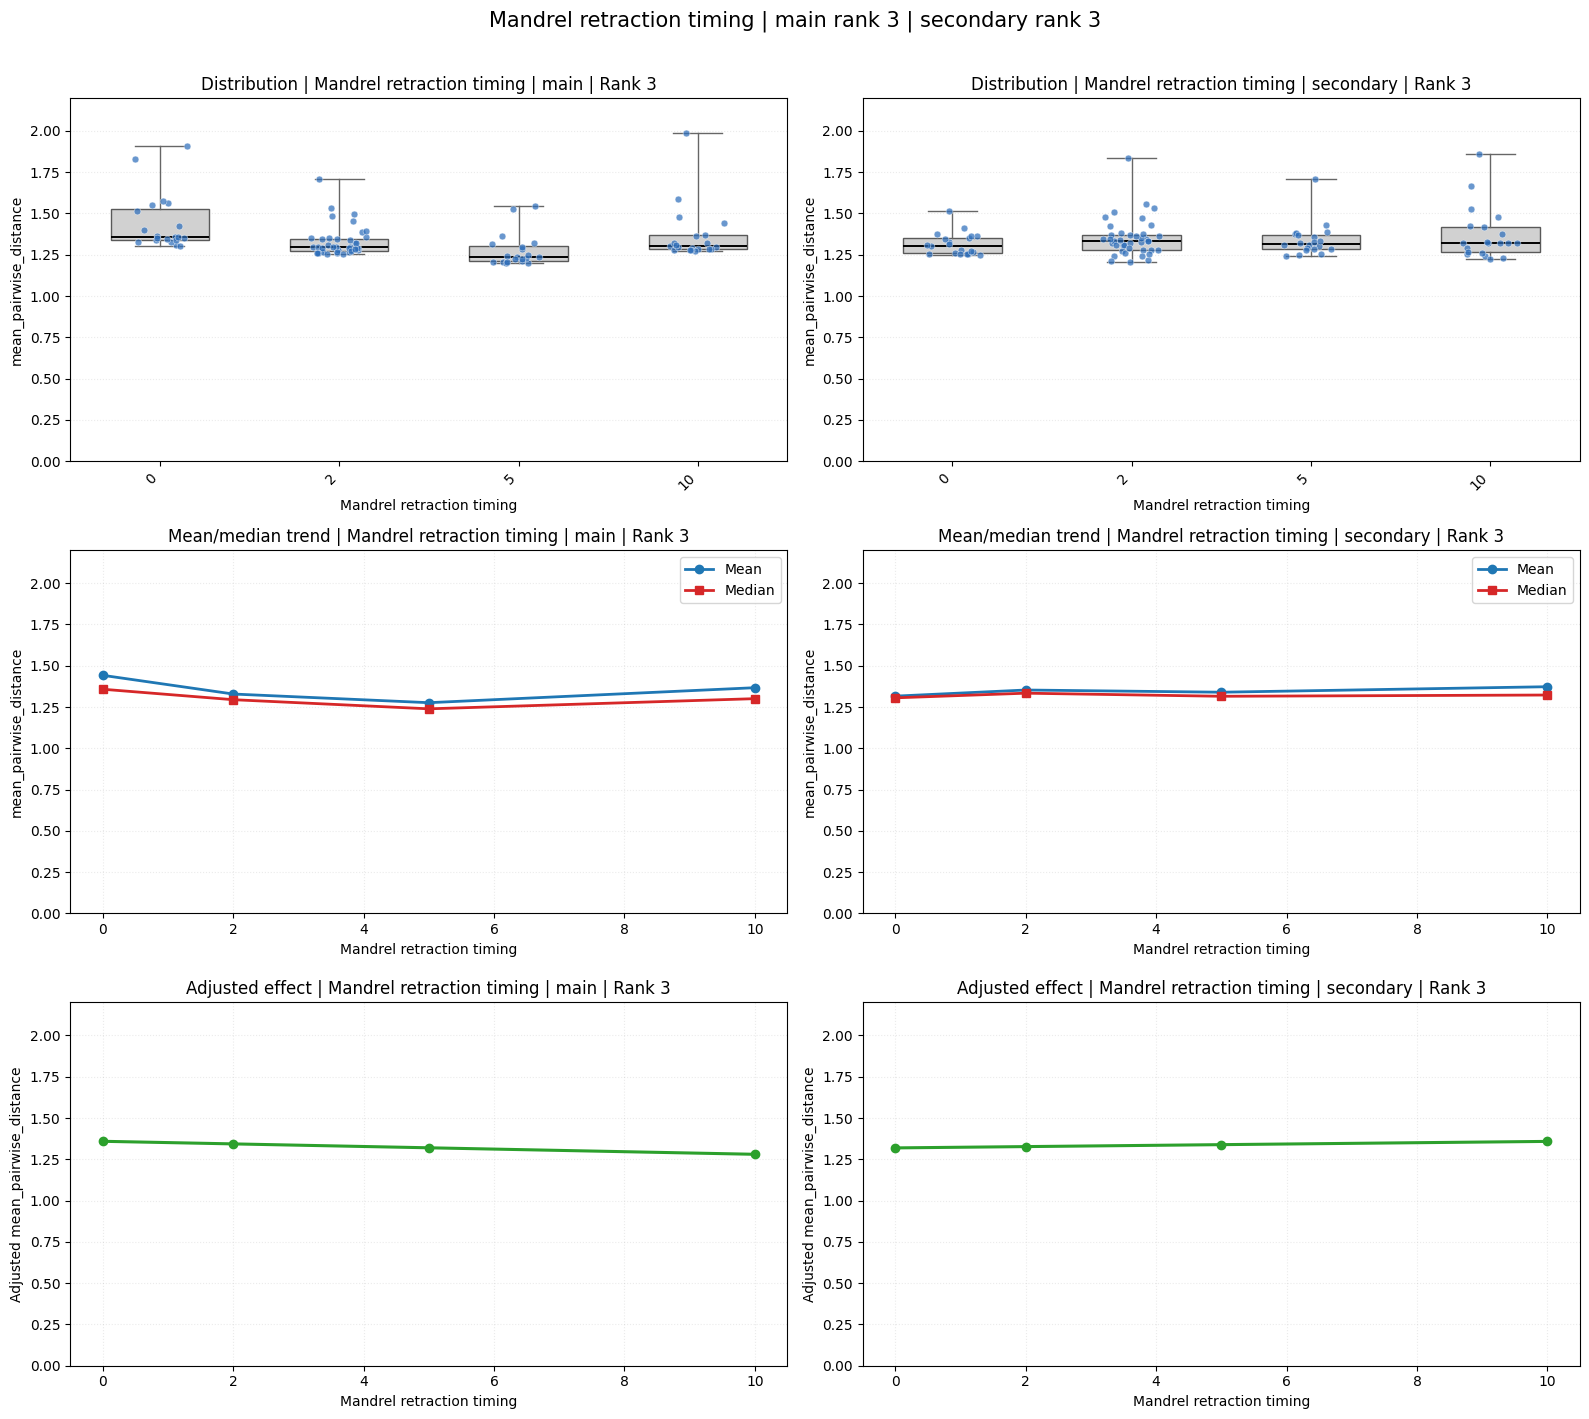

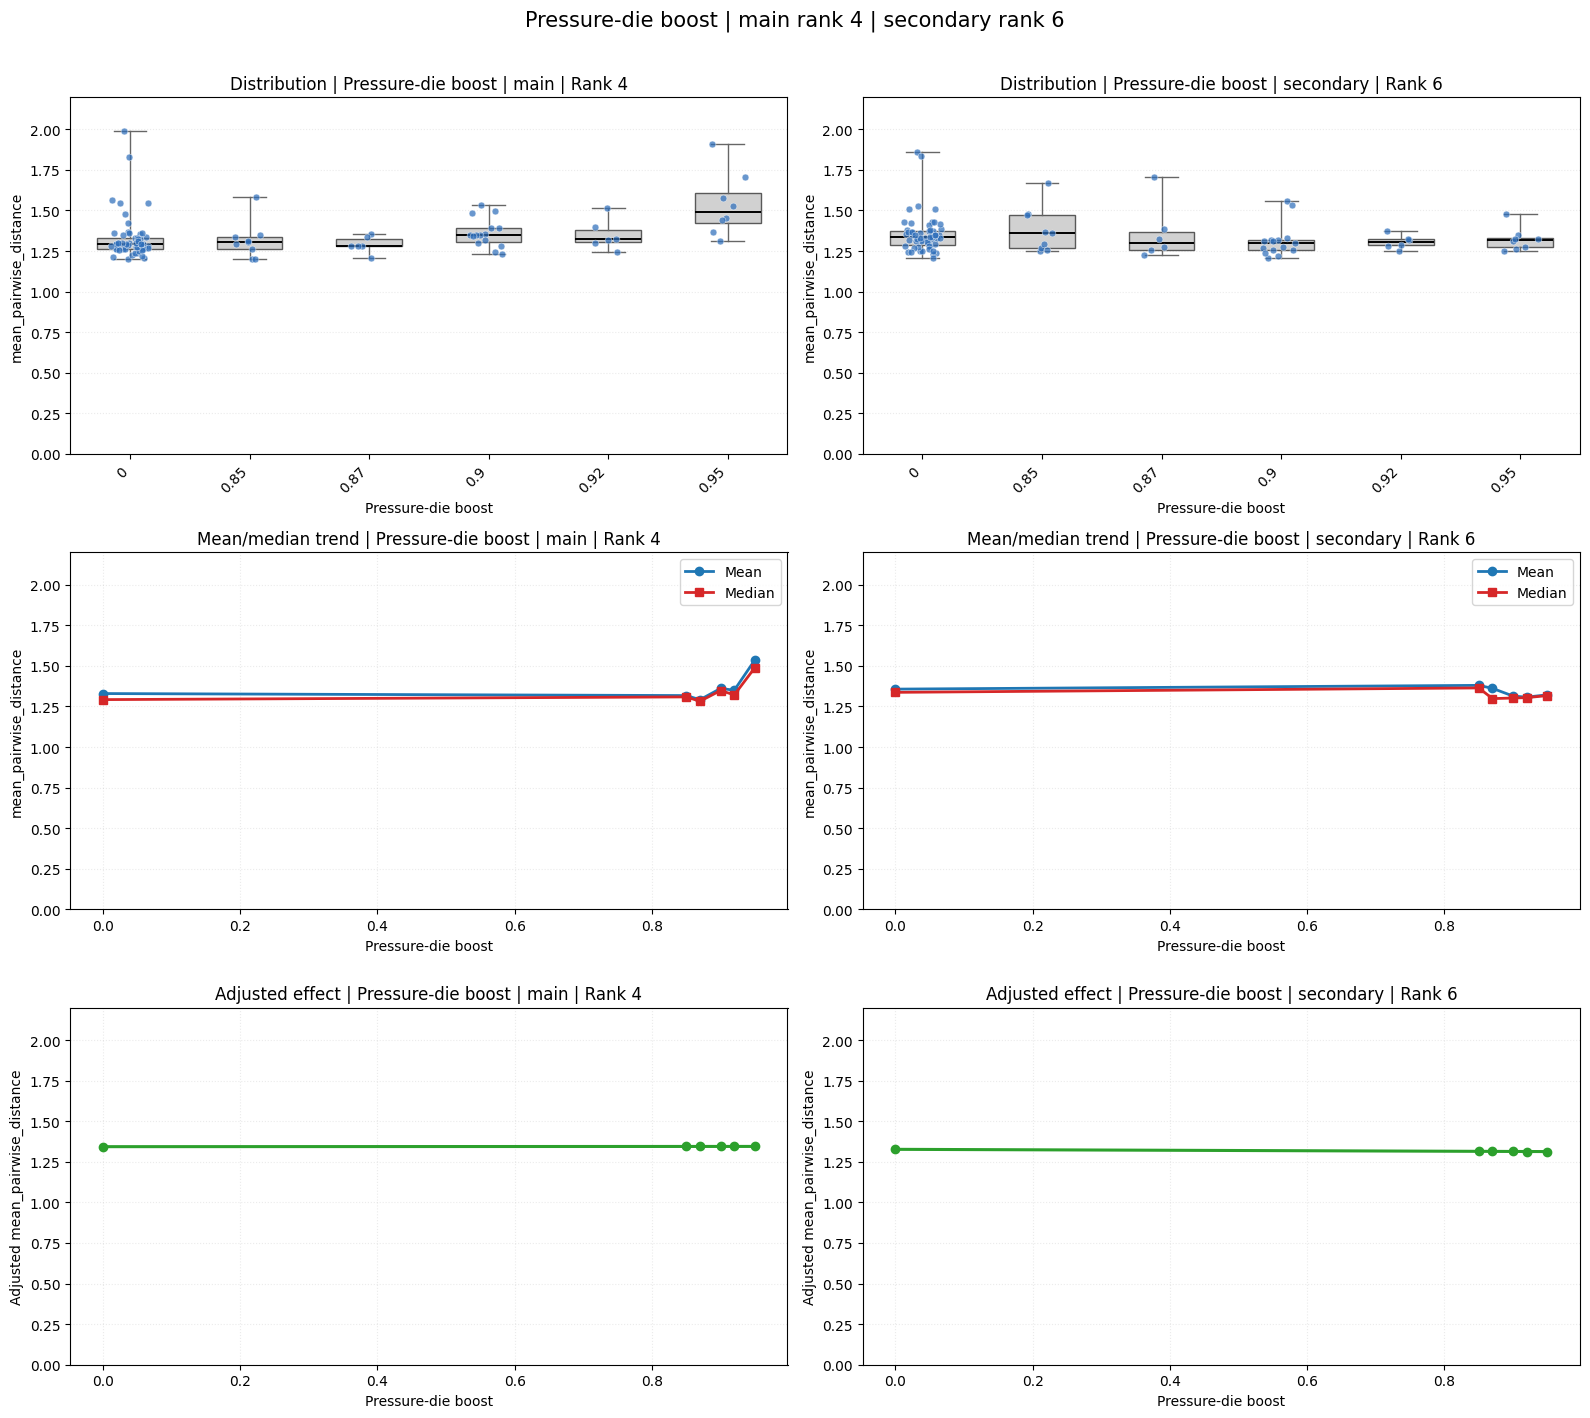

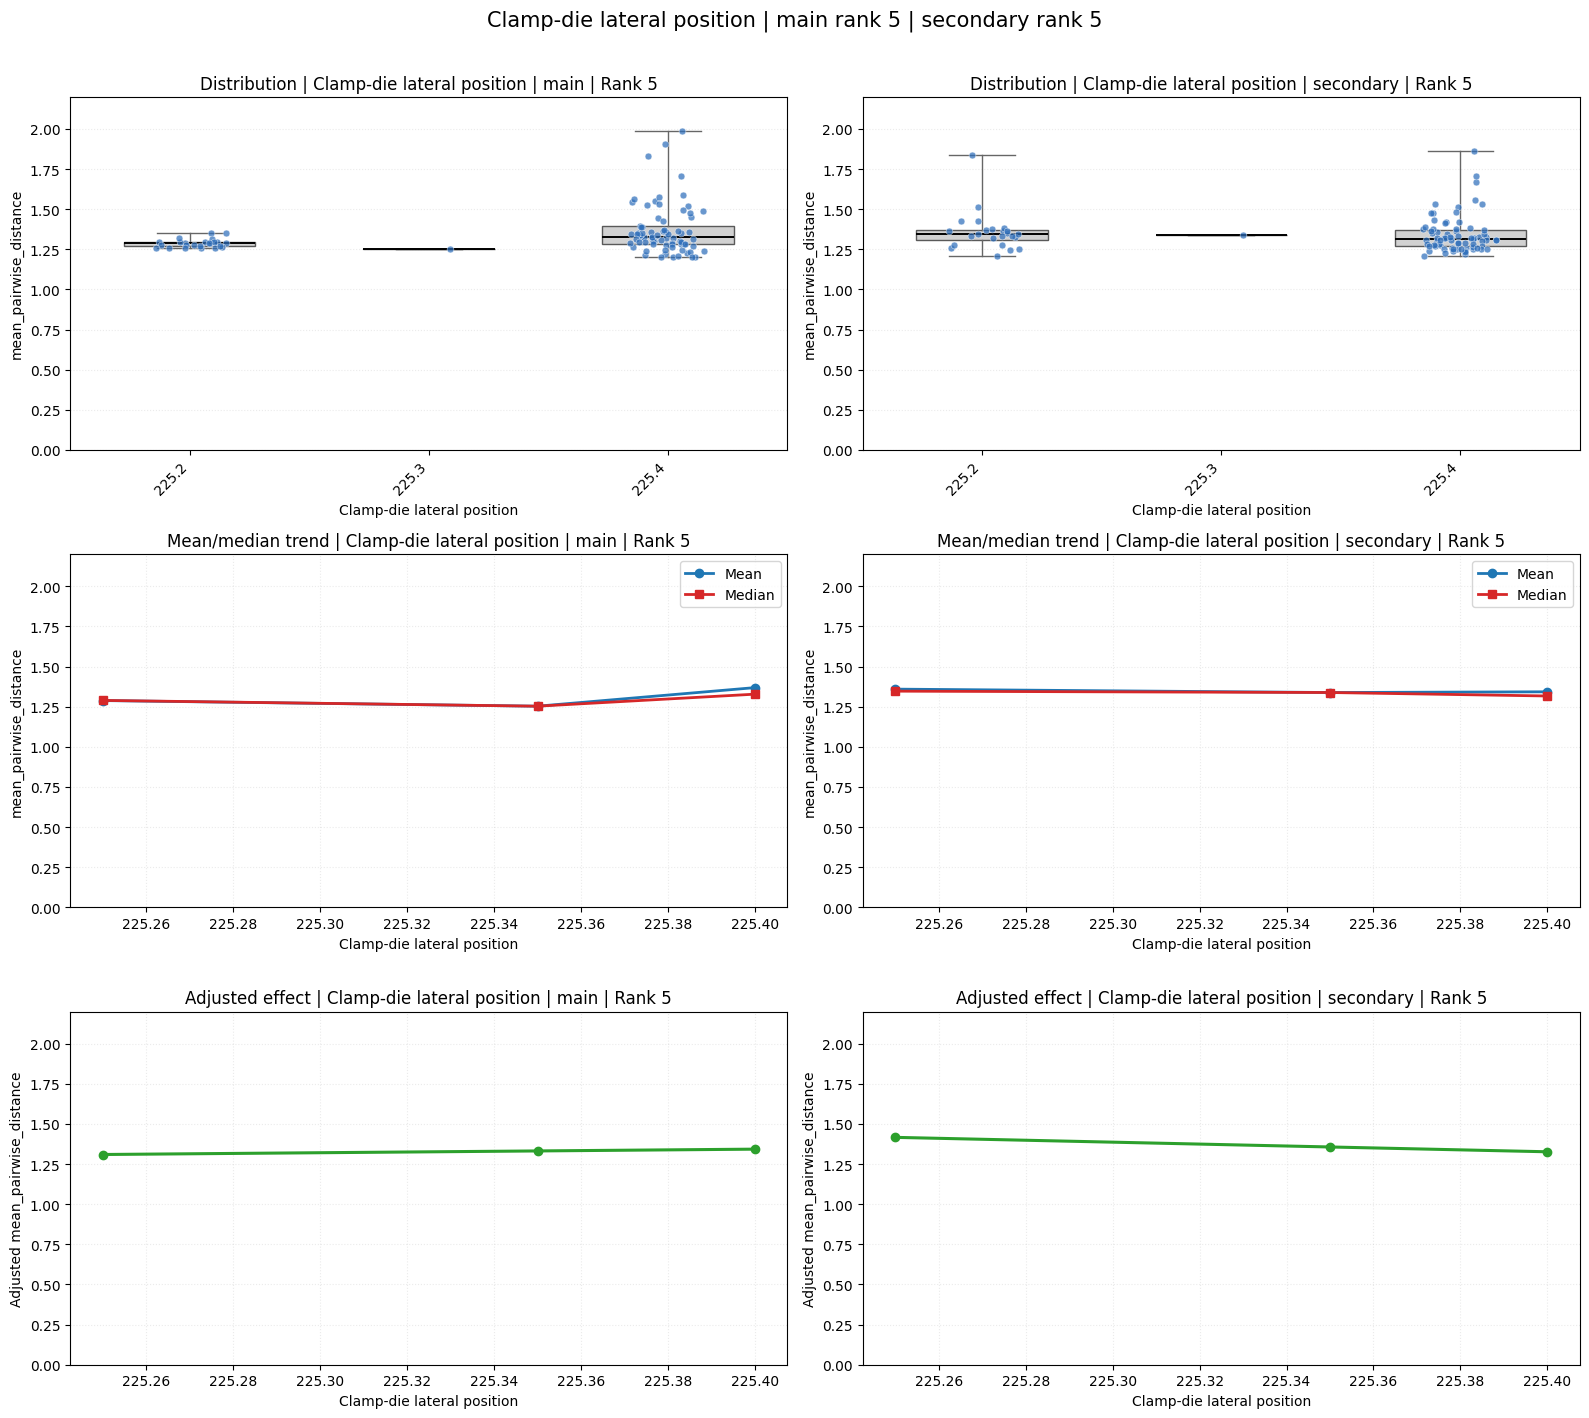

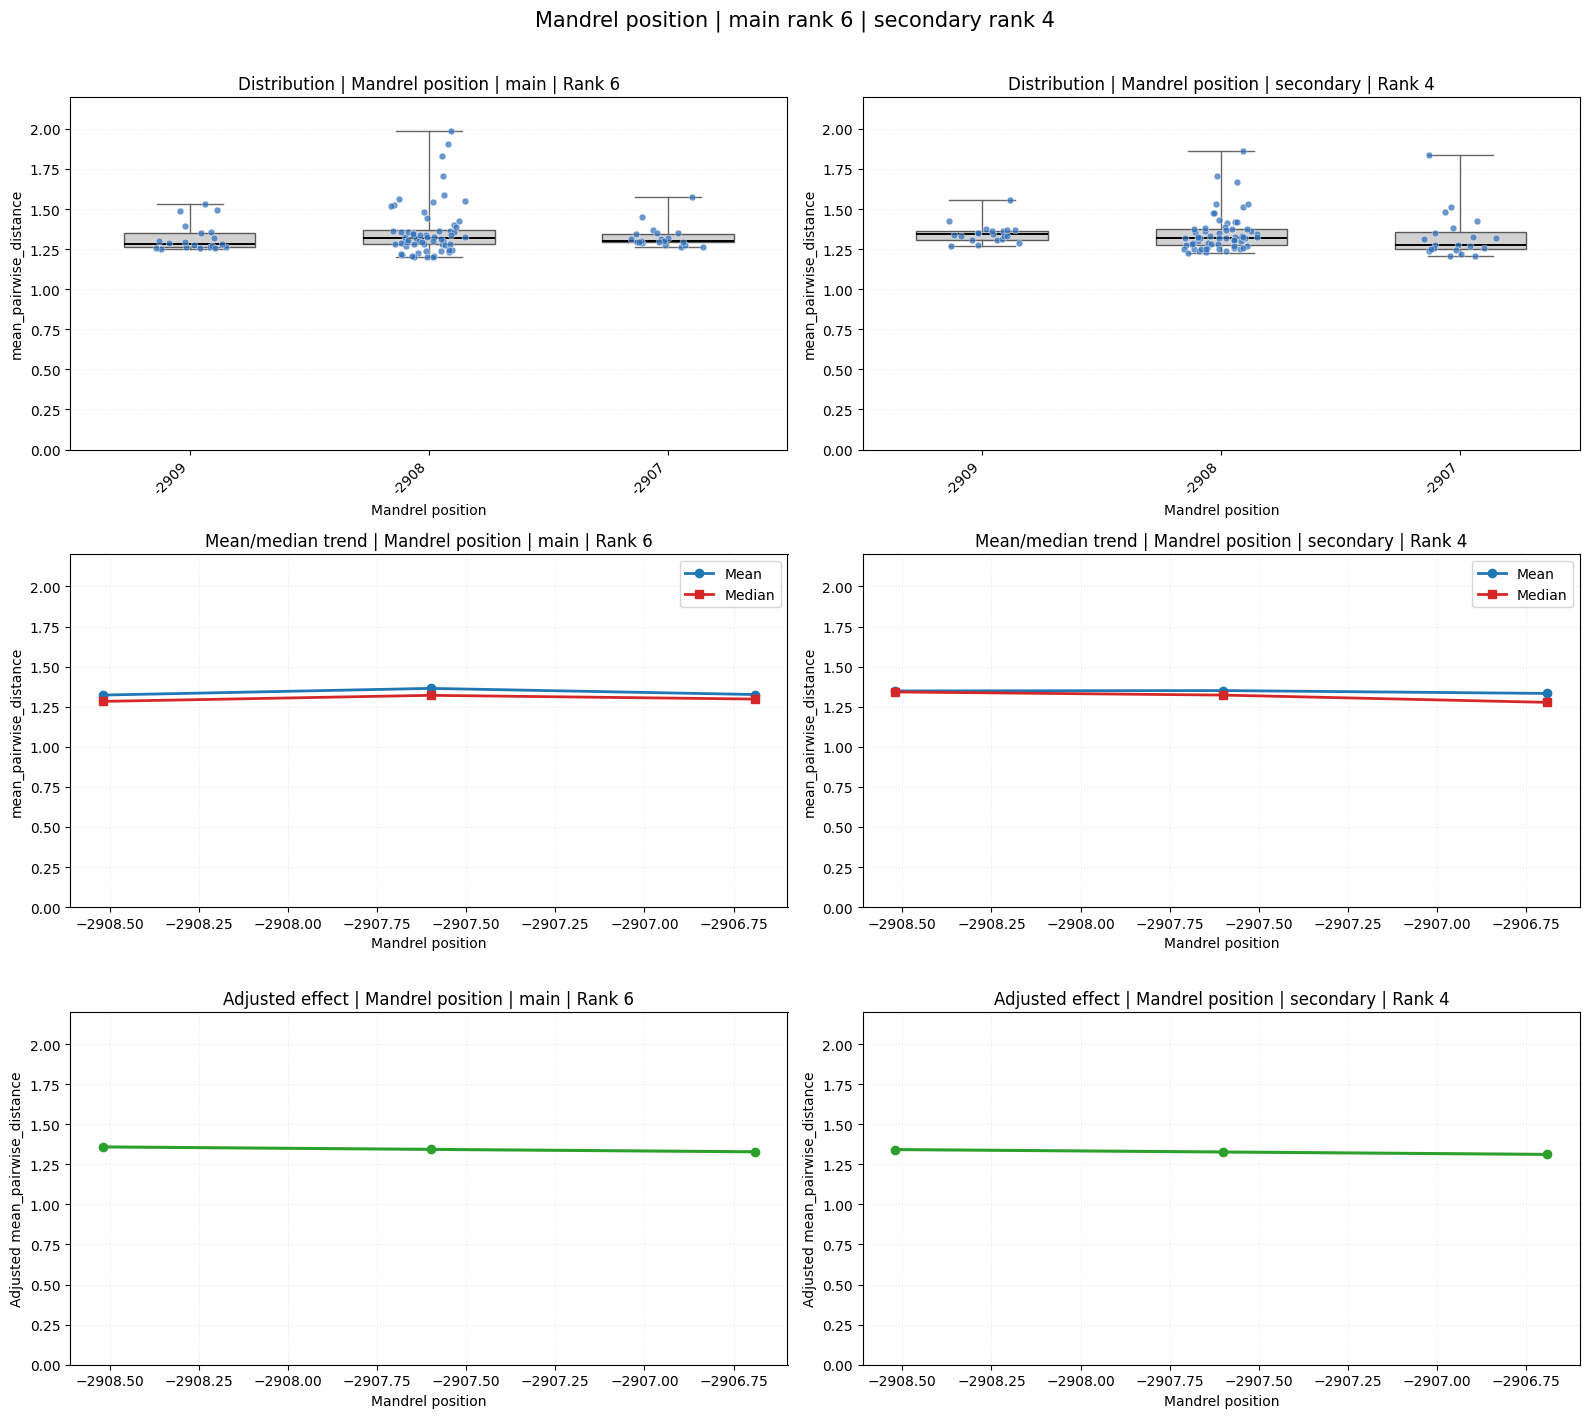

In [15]:
extra_analysis_figures = {}

for feature_name in available_ranked_features:
    main_ranked_features_df, _, feature_column, rank_column, _ = (
        select_ranked_features(
            ranking_data=ranking_df,
            geometry_type="main",
            top_n_features=None,
        )
    )

    secondary_ranked_features_df, _, _, _, _ = (
        select_ranked_features(
            ranking_data=ranking_df,
            geometry_type="secondary",
            top_n_features=None,
        )
    )

    main_rank = main_ranked_features_df.loc[
        main_ranked_features_df[feature_column].eq(feature_name),
        rank_column,
    ].iloc[0]

    secondary_rank = secondary_ranked_features_df.loc[
        secondary_ranked_features_df[feature_column].eq(feature_name),
        rank_column,
    ].iloc[0]

    main_plot_df, _ = build_axis_plot_data(
        feature_name=feature_name,
        geometry_type="main",
        distance_columns=[
            "Angle[degree]ORDistance[mm]",
            "Main-axis [mm]",
        ],
    )

    secondary_plot_df, _ = build_axis_plot_data(
        feature_name=feature_name,
        geometry_type="secondary",
        distance_columns=[
            "Angle[degree]ORDistance[mm]",
            "Secondary-axis [mm]",
        ],
    )

    fig, axes = plt.subplots(
        nrows=3,
        ncols=2,
        figsize=(16, 14),
    )

    plot_metric_distribution_by_feature_value(
        plot_data=main_plot_df,
        feature_name=feature_name,
        metric_name=PAIRWISE_DISTANCE_COLUMN,
        geometry_type=f"main | Rank {int(main_rank)}",
        ax=axes[0, 0],
    )

    plot_metric_distribution_by_feature_value(
        plot_data=secondary_plot_df,
        feature_name=feature_name,
        metric_name=PAIRWISE_DISTANCE_COLUMN,
        geometry_type=f"secondary | Rank {int(secondary_rank)}",
        ax=axes[0, 1],
    )

    plot_metric_mean_median_trend(
        plot_data=main_plot_df,
        feature_name=feature_name,
        metric_name=PAIRWISE_DISTANCE_COLUMN,
        geometry_type=f"main | Rank {int(main_rank)}",
        ax=axes[1, 0],
    )

    plot_metric_mean_median_trend(
        plot_data=secondary_plot_df,
        feature_name=feature_name,
        metric_name=PAIRWISE_DISTANCE_COLUMN,
        geometry_type=f"secondary | Rank {int(secondary_rank)}",
        ax=axes[1, 1],
    )

    plot_adjusted_effect_by_feature_value(
        plot_data=main_plot_df,
        bending_data=bending_setup_df,
        feature_name=feature_name,
        metric_name=PAIRWISE_DISTANCE_COLUMN,
        group_column=bending_group_column,
        geometry_type=f"main | Rank {int(main_rank)}",
        ax=axes[2, 0],
    )

    plot_adjusted_effect_by_feature_value(
        plot_data=secondary_plot_df,
        bending_data=bending_setup_df,
        feature_name=feature_name,
        metric_name=PAIRWISE_DISTANCE_COLUMN,
        group_column=bending_group_column,
        geometry_type=f"secondary | Rank {int(secondary_rank)}",
        ax=axes[2, 1],
    )

    fig.suptitle(
        f"{feature_name} | main rank {int(main_rank)} | secondary rank {int(secondary_rank)}",
        fontsize=15,
        y=1.01,
    )

    fig.tight_layout()

    extra_analysis_figures[feature_name] = fig

    plt.show()

STD based

In [16]:
def build_axis_std_plot_data(
    feature_name: str,
    geometry_type: str,
    distance_columns: list[str],
):
    ranked_features_axis_df, _, feature_column, rank_column, _ = (
        select_ranked_features(
            ranking_data=ranking_df,
            geometry_type=geometry_type,
            top_n_features=None,
        )
    )

    feature_rank = ranked_features_axis_df.loc[
        ranked_features_axis_df[feature_column].eq(feature_name),
        rank_column,
    ].iloc[0]

    group_std_df = compute_group_std_distance(
        dataframe=experiment_df,
        group_column=experiment_group_column,
        distance_columns=distance_columns,
        standardize=True,
    )

    group_std_df = group_std_df.rename(
        columns={
            experiment_group_column: bending_group_column,
        }
    )

    feature_plot_df = build_feature_plot_dataframe(
        feature_name=feature_name,
        bending_data=bending_setup_df,
        group_distance_data=group_std_df,
        bending_group_name=bending_group_column,
        metric_name=STD_DISTANCE_COLUMN,
    )

    return feature_plot_df, feature_rank

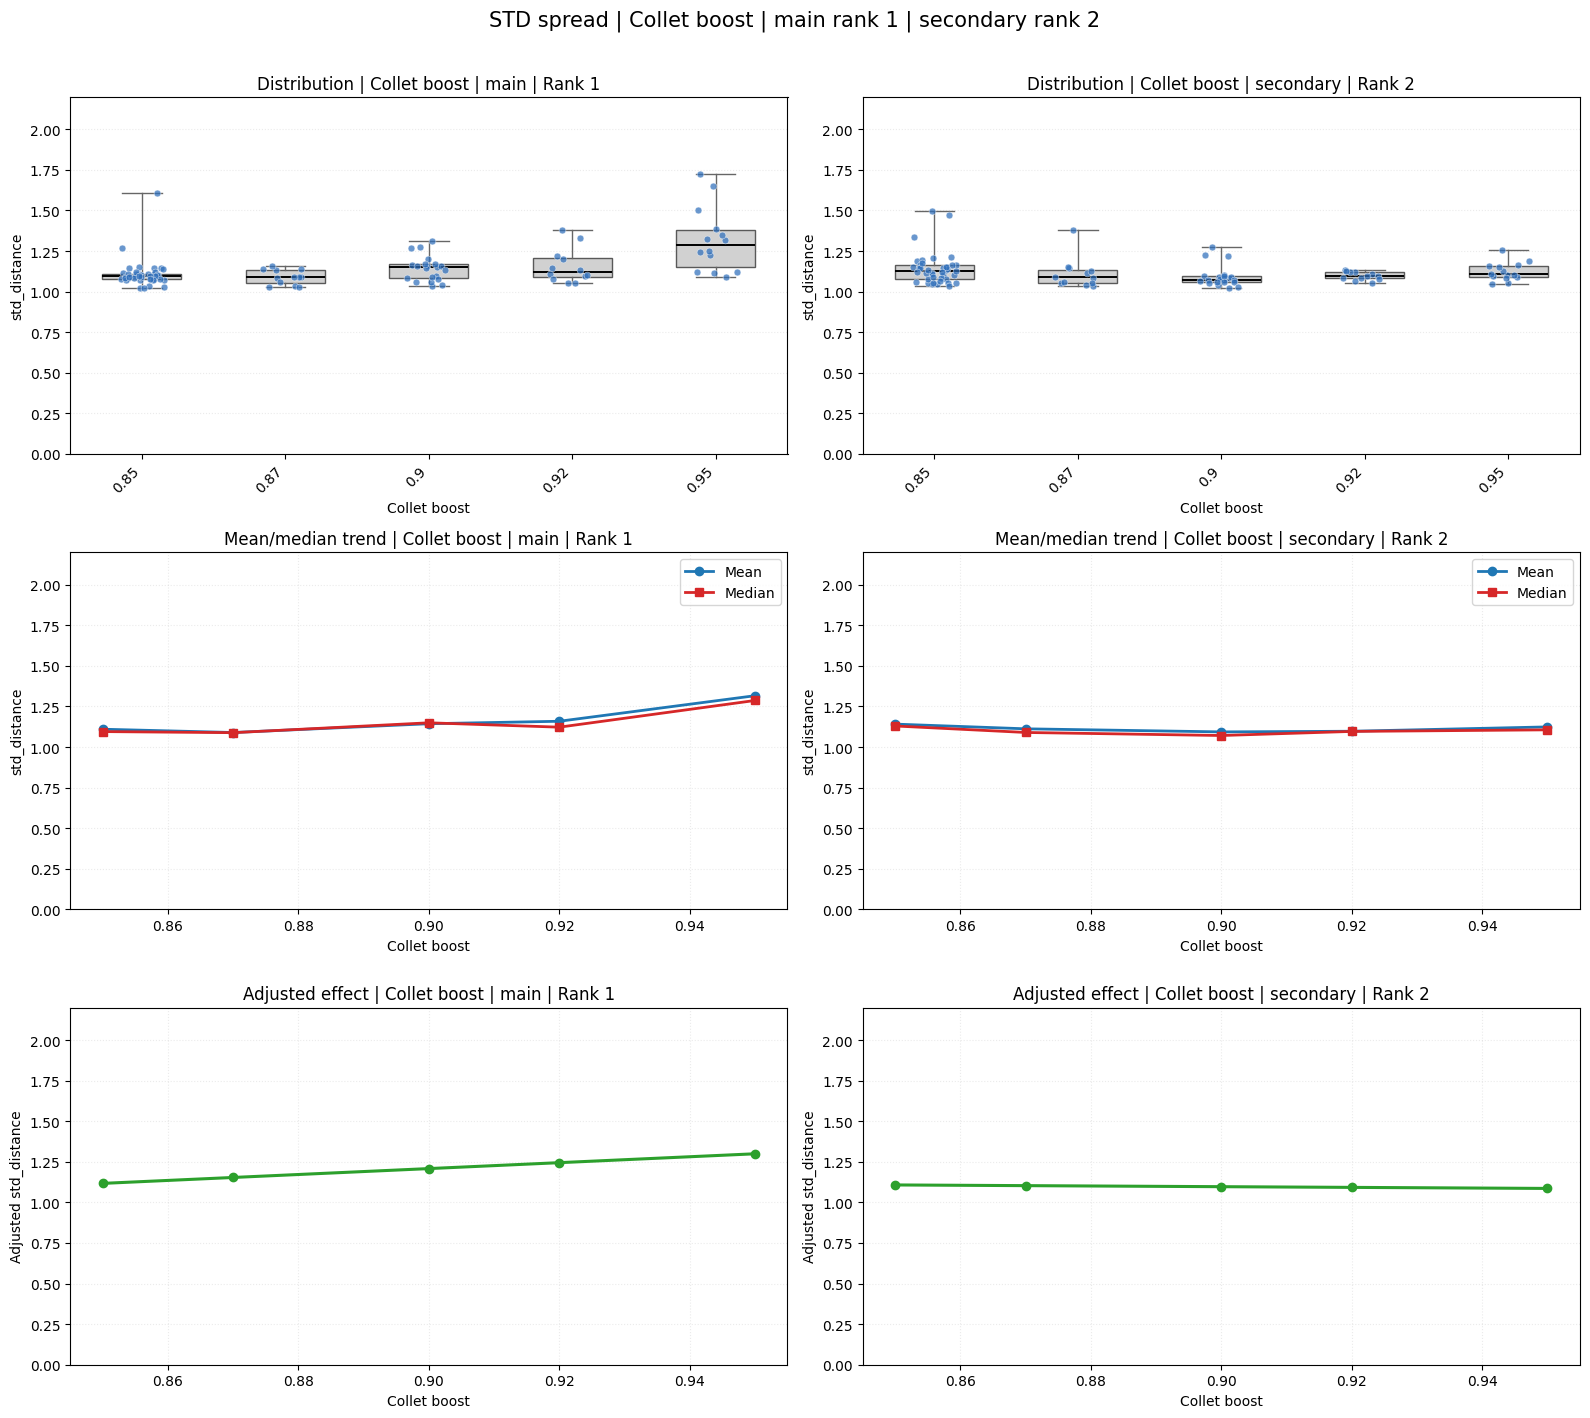

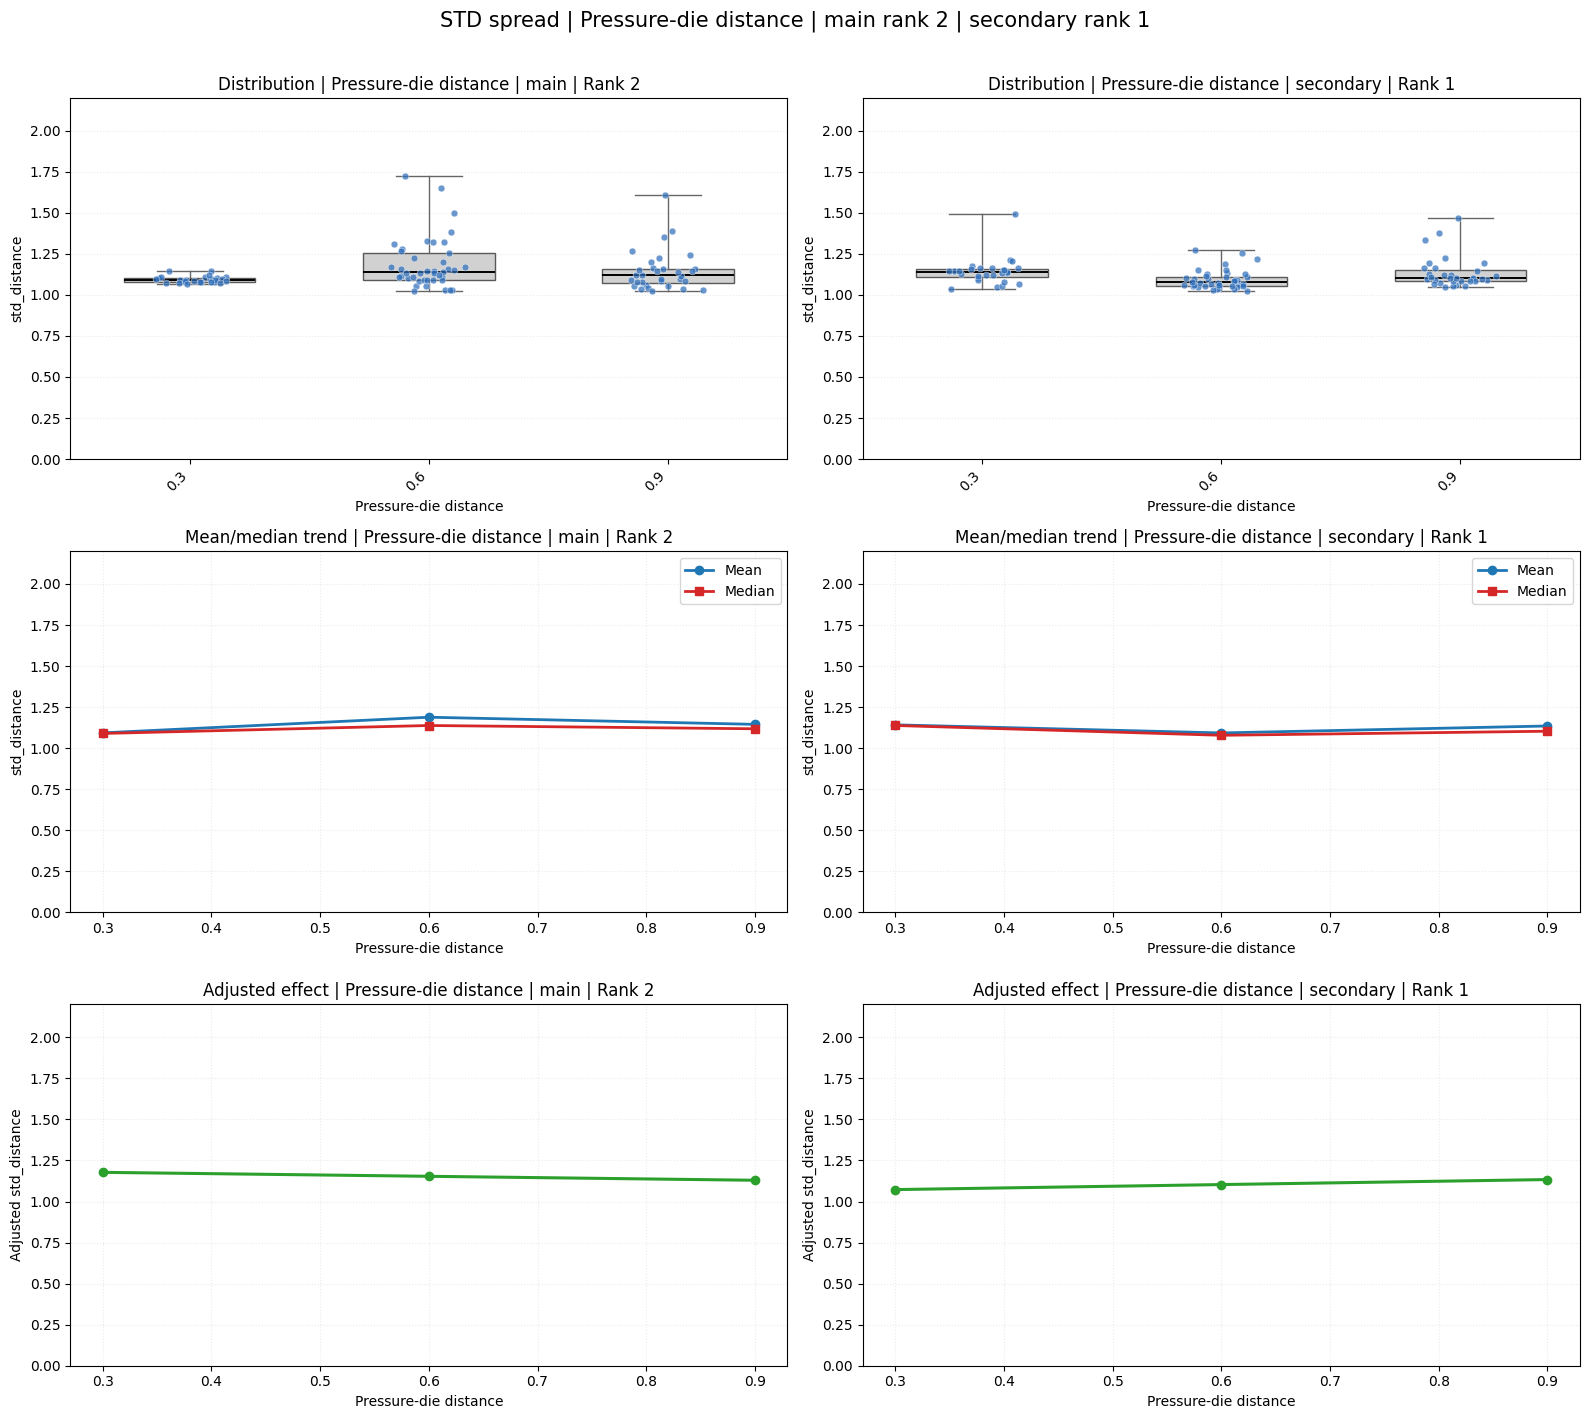

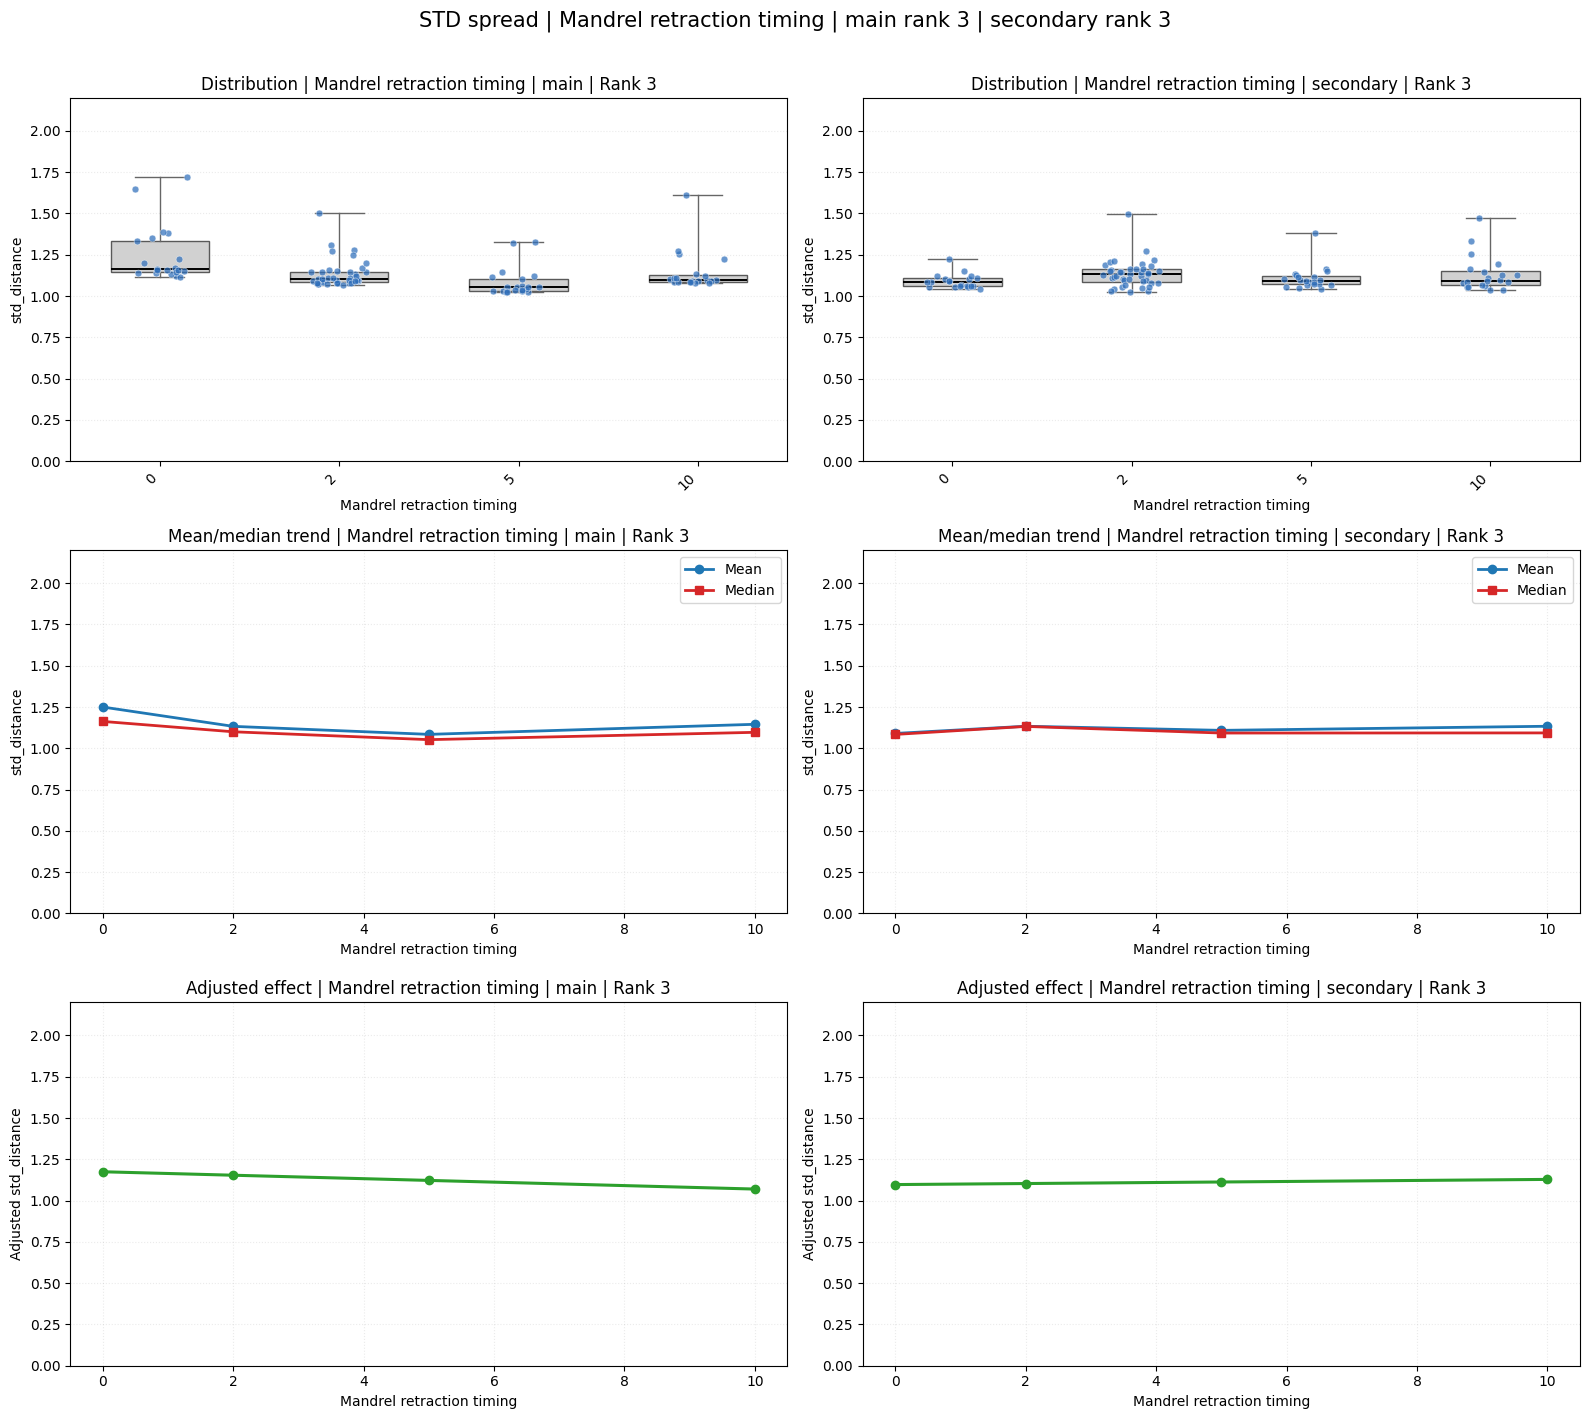

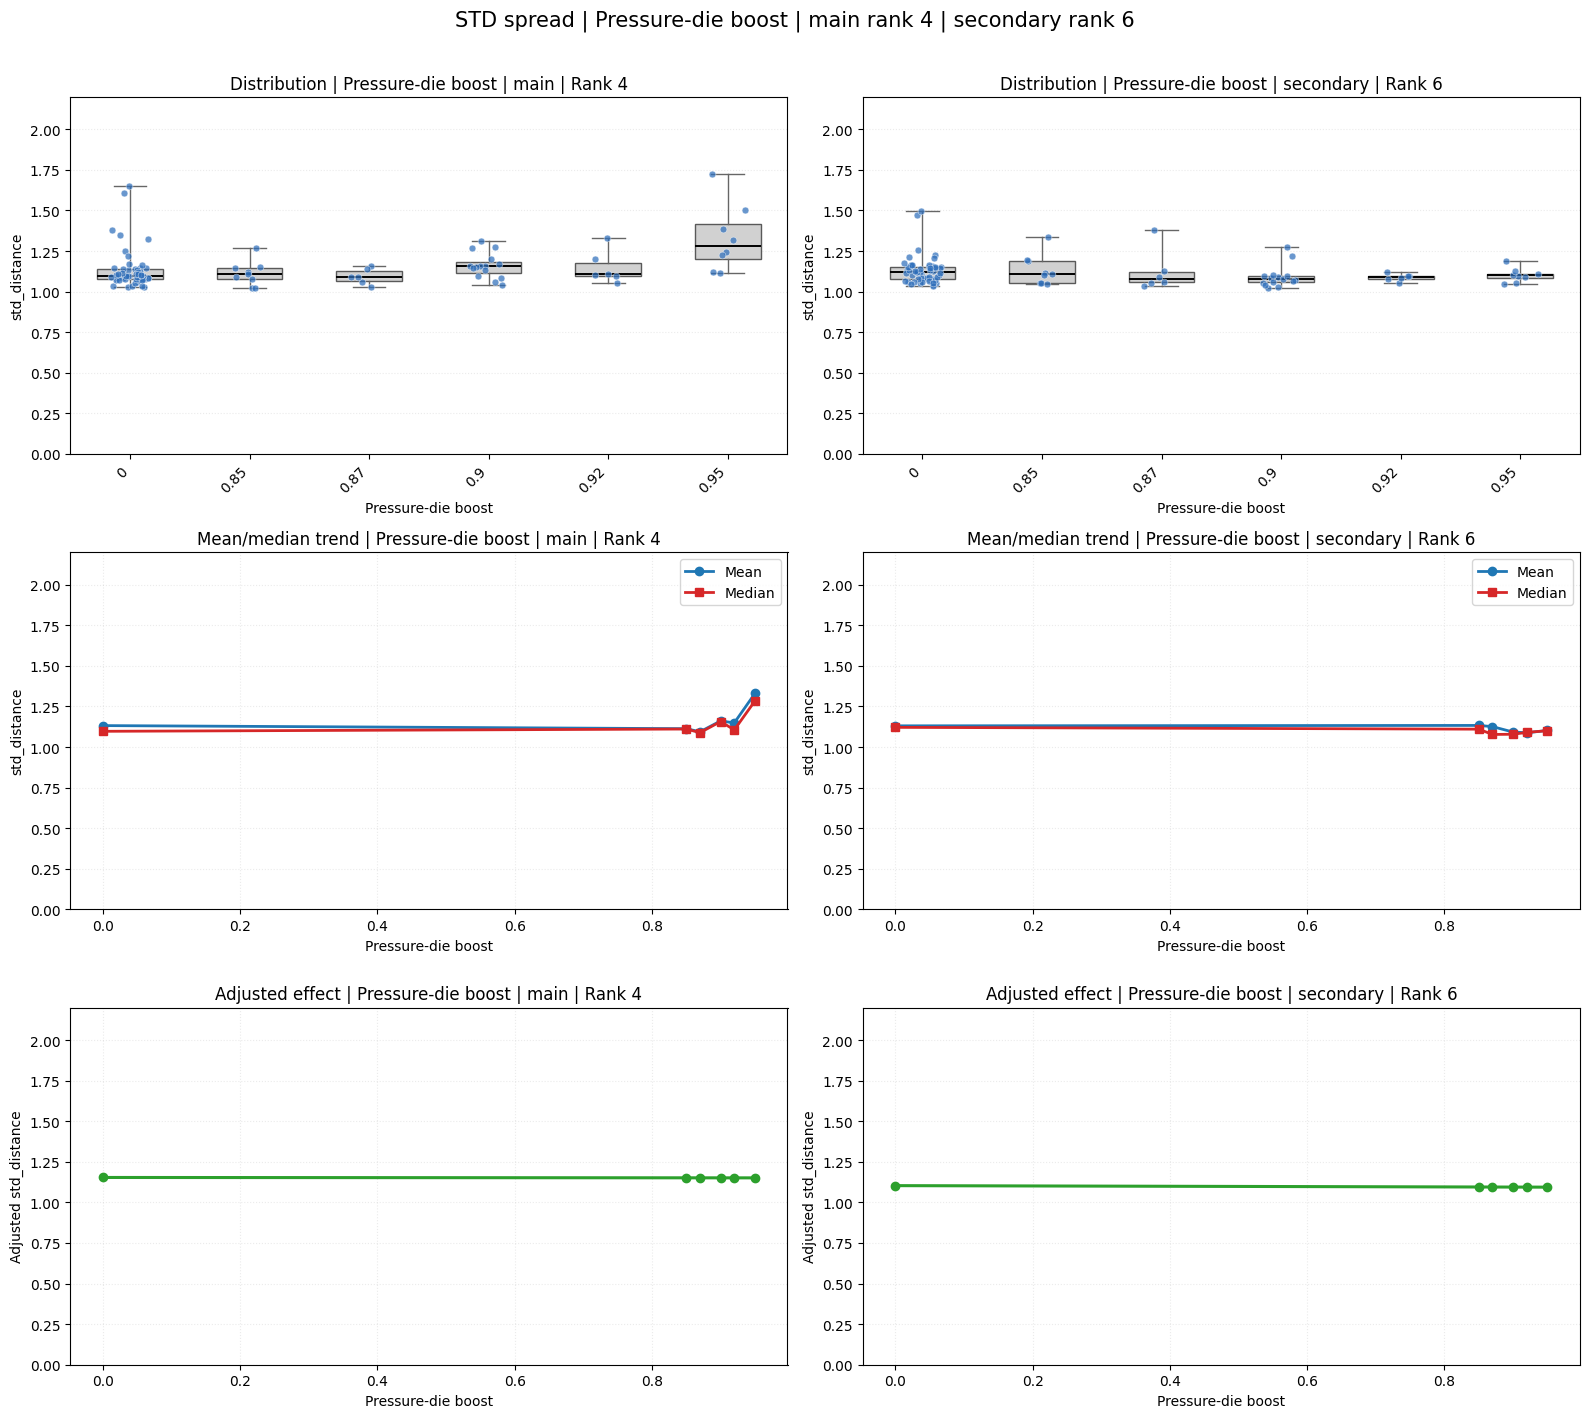

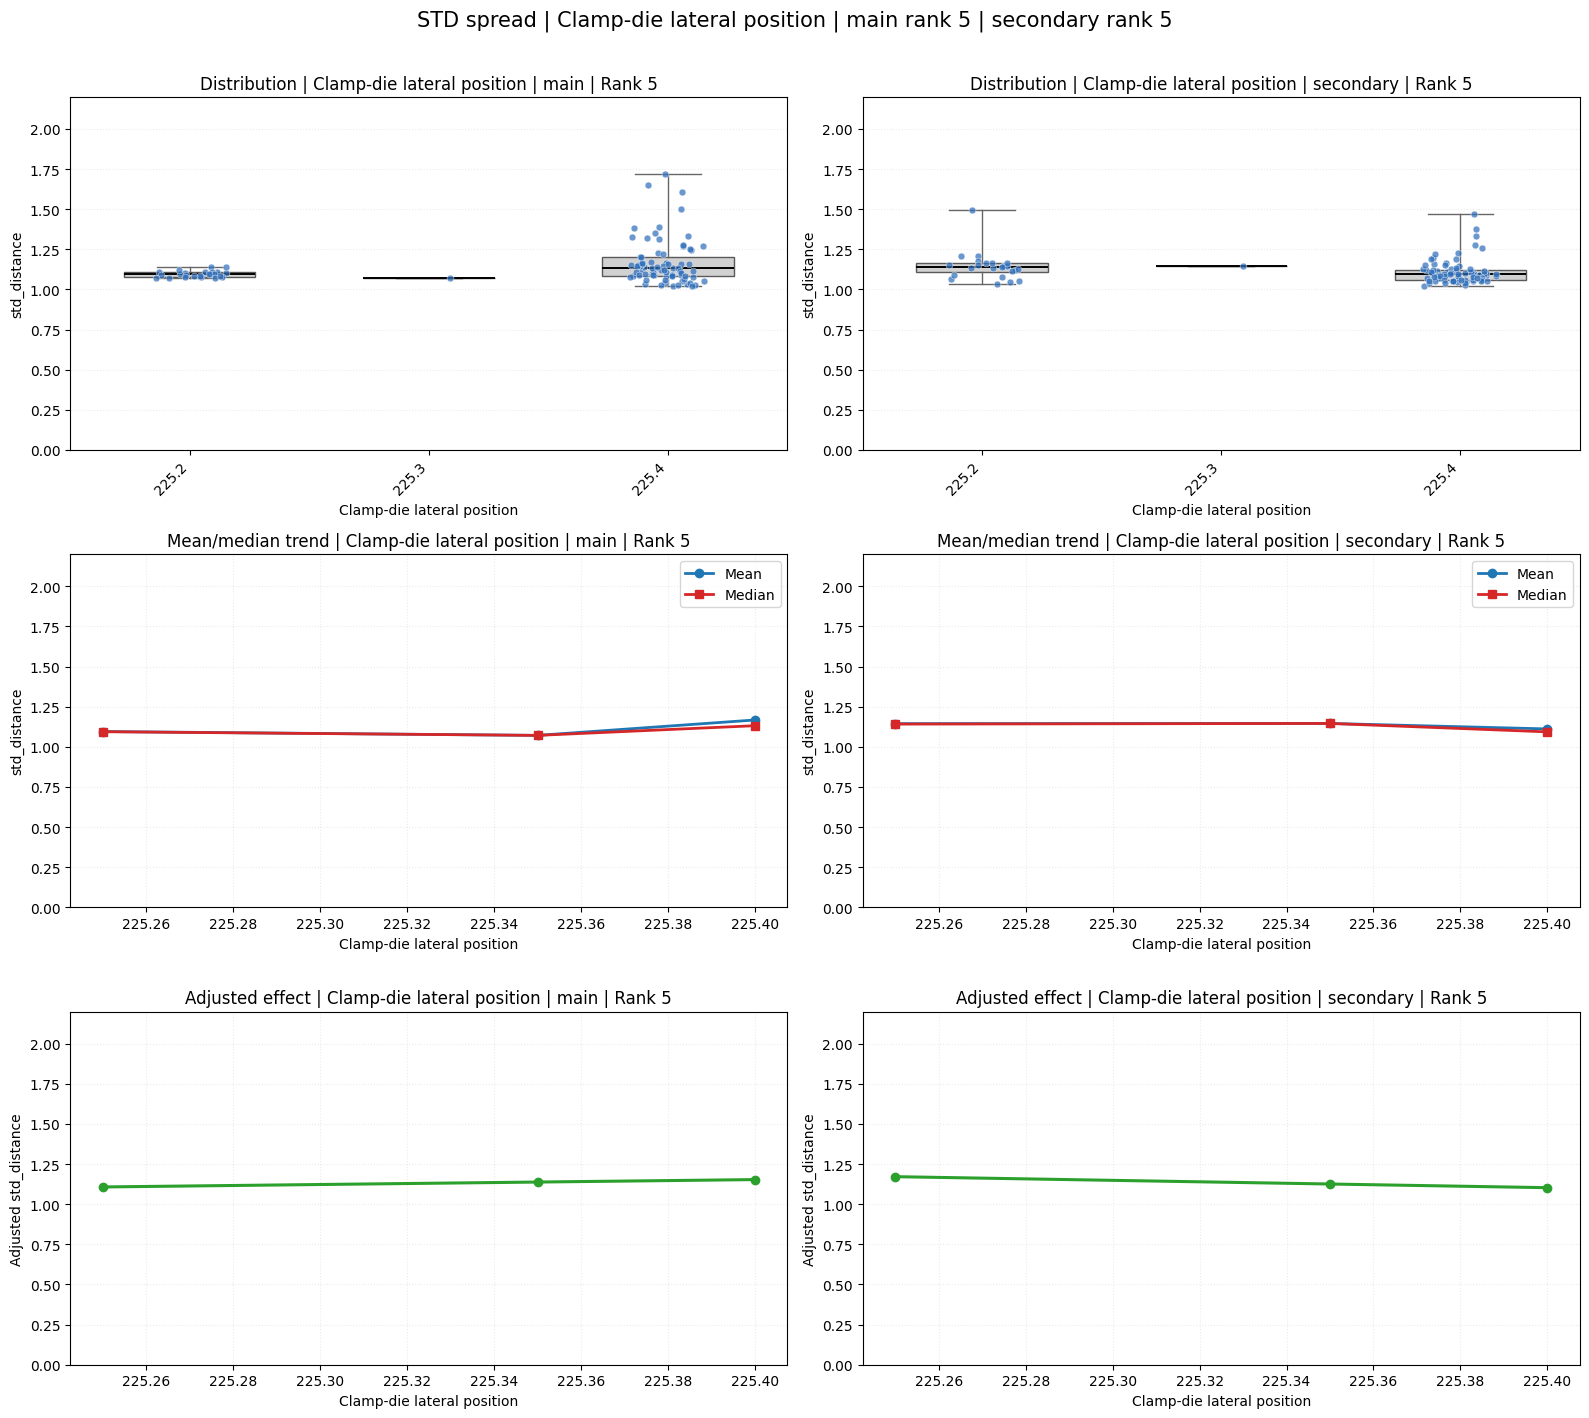

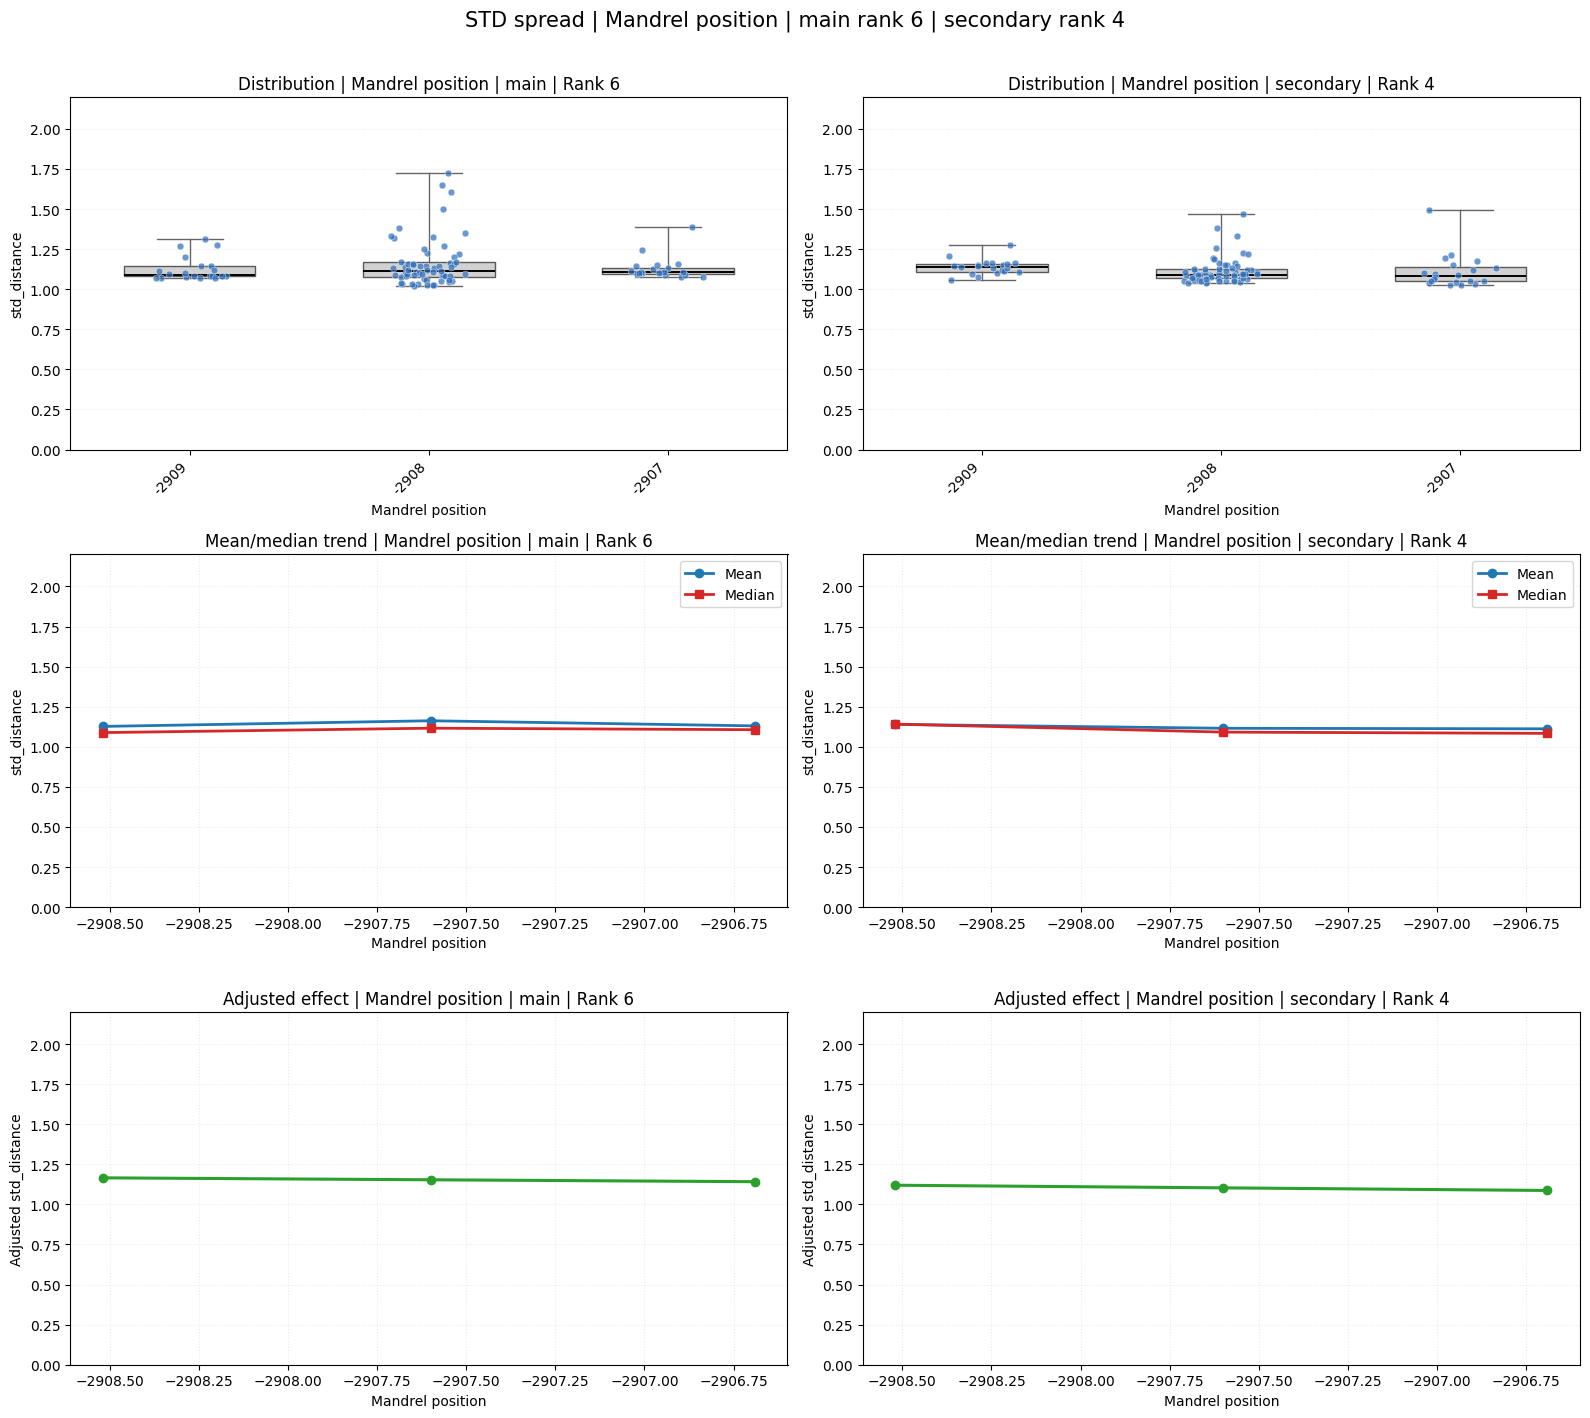

In [17]:
std_analysis_figures = {}

for feature_name in available_ranked_features:
    main_plot_df, main_rank = build_axis_std_plot_data(
        feature_name=feature_name,
        geometry_type="main",
        distance_columns=[
            "Angle[degree]ORDistance[mm]",
            "Main-axis [mm]",
        ],
    )

    secondary_plot_df, secondary_rank = build_axis_std_plot_data(
        feature_name=feature_name,
        geometry_type="secondary",
        distance_columns=[
            "Angle[degree]ORDistance[mm]",
            "Secondary-axis [mm]",
        ],
    )

    fig, axes = plt.subplots(
        nrows=3,
        ncols=2,
        figsize=(16, 14),
    )

    plot_metric_distribution_by_feature_value(
        plot_data=main_plot_df,
        feature_name=feature_name,
        metric_name=STD_DISTANCE_COLUMN,
        geometry_type=f"main | Rank {int(main_rank)}",
        ax=axes[0, 0],
    )

    plot_metric_distribution_by_feature_value(
        plot_data=secondary_plot_df,
        feature_name=feature_name,
        metric_name=STD_DISTANCE_COLUMN,
        geometry_type=f"secondary | Rank {int(secondary_rank)}",
        ax=axes[0, 1],
    )

    plot_metric_mean_median_trend(
        plot_data=main_plot_df,
        feature_name=feature_name,
        metric_name=STD_DISTANCE_COLUMN,
        geometry_type=f"main | Rank {int(main_rank)}",
        ax=axes[1, 0],
    )

    plot_metric_mean_median_trend(
        plot_data=secondary_plot_df,
        feature_name=feature_name,
        metric_name=STD_DISTANCE_COLUMN,
        geometry_type=f"secondary | Rank {int(secondary_rank)}",
        ax=axes[1, 1],
    )

    plot_adjusted_effect_by_feature_value(
        plot_data=main_plot_df,
        bending_data=bending_setup_df,
        feature_name=feature_name,
        metric_name=STD_DISTANCE_COLUMN,
        group_column=bending_group_column,
        geometry_type=f"main | Rank {int(main_rank)}",
        ax=axes[2, 0],
    )

    plot_adjusted_effect_by_feature_value(
        plot_data=secondary_plot_df,
        bending_data=bending_setup_df,
        feature_name=feature_name,
        metric_name=STD_DISTANCE_COLUMN,
        group_column=bending_group_column,
        geometry_type=f"secondary | Rank {int(secondary_rank)}",
        ax=axes[2, 1],
    )

    fig.suptitle(
        f"STD spread | {feature_name} | main rank {int(main_rank)} | secondary rank {int(secondary_rank)}",
        fontsize=15,
        y=1.01,
    )

    fig.tight_layout()

    std_analysis_figures[feature_name] = fig

    plt.show()